# 🏎️ Predicting F1 Pit Stop Duration with Machine Learning

**Author:** Saurabh Gupta | IIT (ISM) Dhanbad, B.Tech Mineral & Metallurgical Engineering (2024–2028)  
**GitHub:** [Saurabh6266](https://github.com/Saurabh6266) | **Email:** saurabh.iitian62@gmail.com

---

## Project Overview   
Formula 1 pit stops are among the most time-critical operations in motorsport. The difference between a 2.5-second tyre change and a 4-second one can mean the difference between winning and losing a race position. Across a full season, cumulative pit stop performance has directly shaped championship outcomes — Ferrari's operational pace in the early 2000s and Red Bull's dominance in the early 2010s were both partly built on pit crew excellence.

This project uses 17 seasons of F1 pit stop timing data (1994–2010) to ask a concrete question:

> **Can machine learning predict how long a pit stop will take, using only information about the team, driver, circuit, stop number, and historical performance?**

The dataset covers a structurally fascinating window in F1 history. From 1994 to 2009, refueling was permitted during races — pit stops included loading fuel, which added anywhere from 5 to 45 seconds depending on strategy. In 2010, refueling was banned and stops became tyre-only operations. This rule change is not just a footnote; it defines the entire shape of the data and becomes the most important thing the models will learn.

### What this notebook covers
- **Task A — Regression:** Predict the exact duration of a pit stop in seconds.
- **Task B — Classification:** Classify a stop as fast, normal, or slow (3-class), and as below or above the median (binary).

The pipeline runs from raw data through leakage auditing, preprocessing, EDA, feature engineering, baseline models, a full model comparison (Linear Regression through LightGBM), hyperparameter tuning with TimeSeriesSplit, SHAP-based interpretability, error analysis, learning curves, model stacking, and calibration analysis.

---
> **Dataset:** [Pitstop Pulse: Formula 1 Performance Data](https://www.kaggle.com/datasets/eshummalik/pitstop-pulse-formula-1-performance-data) — 9,921 rows, 13 columns, 288 races across 17 seasons (1994–2010).   
> **Source**: Kaggle

In [1]:
# Standard Library
import warnings
import os
warnings.filterwarnings("ignore")

# Core Data
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Baselines 
from sklearn.dummy import DummyRegressor

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier,
    StackingRegressor
)
from sklearn.svm import SVR, SVC
from sklearn.neural_network import MLPRegressor, MLPClassifier

# XGBoost & LightGBM
try:
    import xgboost as xgb
    print(f"XGBoost  : {xgb.__version__}")
except ImportError:
    print("XGBoost not installed. Run: pip install xgboost")

try:
    import lightgbm as lgb
    print(f"LightGBM : {lgb.__version__}")
except ImportError:
    print("LightGBM not installed. Run: pip install lightgbm")

# SHAP 
try:
    import shap
    print(f"SHAP version: {shap.__version__}")
except ImportError:
    print("SHAP not installed. Run: pip install shap")

# Evaluation & Tuning 
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import (
    RandomizedSearchCV, learning_curve, TimeSeriesSplit
)
from scipy.stats import randint, uniform

# Global Config
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.titlesize"    : 13,
    "axes.labelsize"    : 11,
})
sns.set_palette("husl")

DATA_PATH = "pitstops.csv"
print("\n✅ Environment ready.")

XGBoost  : 3.2.0
LightGBM : 4.6.0
SHAP version: 0.51.0

✅ Environment ready.


---
## Section 1 — Data Loading

The dataset is structured at the pit stop event level — each row is one pit stop by one driver in one race. The thirteen columns tell us who stopped (DriverName, Code, Car), when in the race (Lap, TimeOfDay), how many stops this driver has made so far (Stops), and how long the stop took (Time, Total).


In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Shape  : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Memory : {df_raw.memory_usage(deep=True).sum() / 1e6:.2f} MB\n")
df_raw.head(10)

Shape  : 9,921 rows × 13 columns
Memory : 4.45 MB



,RaceId,DriverId,Stops,Year,Race,No,DriverName,Code,Car,Lap,TimeOfDay,Time,Total
0,258,100,1,1994,pacific,20,Erik Comas,COM,Larrousse Ford,1,14:01:34,49.111,49.111
1,258,79,1,1994,pacific,3,Ukyo Katayama,KAT,Tyrrell Yamaha,17,14:20:46,28.482,28.482
2,258,57,1,1994,pacific,7,Mika Hakkinen,HAK,McLaren Peugeot,18,14:22:35,43.745,43.745
3,258,71,1,1994,pacific,0,Damon Hill,HIL,Williams Renault,18,14:23:00,21.992,21.992
4,258,105,1,1994,pacific,24,Michele Alboreto,ALB,Minardi Ford,19,14:24:39,27.693,27.693
5,258,91,1,1994,pacific,29,Karl Wendlinger,WEN,Sauber Mercedes,19,14:24:41,24.806,24.806
6,258,44,1,1994,pacific,26,Olivier Panis,PAN,Ligier Renault,18,14:25:13,53.89,53.890
7,258,94,1,1994,pacific,23,Pierluigi Martini,MAR,Minardi Ford,22,14:28:34,34.437,34.437
8,258,30,1,1994,pacific,5,Michael Schumacher,MSC,Benetton Ford,23,14:28:40,23.342,23.342
9,258,104,1,1994,pacific,9,Christian Fittipaldi,FIT,Footwork Ford,23,14:29:00,56.753,56.753


In [3]:
# Data types and null overview
print("─── Column info ───────────────────────────────────────────────────────")
info_df = pd.DataFrame({
    "dtype"   : df_raw.dtypes,
    "non_null": df_raw.notna().sum(),
    "null_%"  : (df_raw.isna().mean() * 100).round(2),
    "unique"  : df_raw.nunique(),
})
print(info_df.to_string())

─── Column info ───────────────────────────────────────────────────────
             dtype  non_null  null_%  unique
RaceId       int64      9921    0.00     288
DriverId     int64      9921    0.00     119
Stops        int64      9921    0.00       6
Year         int64      9921    0.00      17
Race        object      9921    0.00      27
No           int64      9921    0.00      33
DriverName  object      9921    0.00     119
Code        object      9921    0.00     106
Car         object      9920    0.01      71
Lap          int64      9921    0.00      73
TimeOfDay   object      9921    0.00    5675
Time        object      9918    0.03    7809
Total       object      9921    0.00    9039


In [4]:
# Numeric columns only for describe; Time and Total are strings so they won't appear here yet
df_raw.describe(percentiles=[.05, .25, .5, .75, .95]).T

,count,mean,std,min,5%,25%,50%,75%,95%,max
RaceId,9921.0,142.586231,91.465460,1.0,14.0,68.0,129.0,213.0,340.0,355.0
DriverId,9921.0,42.631791,85.404022,1.0,3.0,15.0,25.0,53.0,87.0,812.0
Stops,9921.0,1.607600,0.749017,1.0,1.0,1.0,1.0,2.0,3.0,6.0
Year,9921.0,2002.527467,4.816939,1994.0,1995.0,1998.0,2003.0,2007.0,2010.0,2010.0
No,9921.0,11.862312,7.312977,0.0,1.0,5.0,11.0,18.0,23.0,34.0
Lap,9921.0,29.613648,13.890129,1.0,7.0,19.0,28.0,41.0,52.0,73.0


### 🔍 Observations
The dataset is clean in structure — only 3 null values in `Time` and 1 in `Car`, out of 9,921 rows. The most important structural issue is that `Time` and `Total` are both stored as strings. Most values are plain float strings like `"49.111"`, but 219 values use a `M:SS.sss` format such as `"1:09.764"`. These represent stops longer than 60 seconds and must be parsed before any arithmetic is attempted.

`Stops` is the ordinal stop number for that driver in that race — 1 = first stop, 2 = second stop, and so on. It is not the total number of stops a driver makes in the race. `Total` is the cumulative pit stop time for that driver up to and including the current stop.

`RaceId` and `DriverId` are database surrogate keys with no inherent mathematical meaning. `No` is the driver's car number, which in this era was assigned by the constructor's championship standing from the previous year (Car 1 = reigning World Champion's team, Car 0 appeared once in 1994 for Damon Hill after Ayrton Senna's death).


---
## Section 2 — Parsing the Time Columns

`Time` and `Total` must be converted to float seconds before any analysis. A single function handles both the plain-seconds format and the `M:SS.sss` format.

In [5]:
def parse_time_to_seconds(val):
    """
    Converts F1 pit stop duration strings to float seconds.
    Handles:
        '49.111'   → 49.111  (plain seconds)
        '1:09.764' → 69.764  (minutes:seconds.milliseconds)
    """
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if ':' in val:
        parts = val.split(':')
        return float(parts[0]) * 60 + float(parts[1])
    return float(val)

df_raw['Time_sec']  = df_raw['Time'].apply(parse_time_to_seconds)
df_raw['Total_sec'] = df_raw['Total'].apply(parse_time_to_seconds)

print("Time_sec — descriptive stats:")
print(df_raw['Time_sec'].describe(percentiles=[.05, .25, .5, .75, .95, .99]).round(3))
print(f"\nStops exceeding 120s : {(df_raw['Time_sec'] > 120).sum()}")
print(f"Stops exceeding  60s : {(df_raw['Time_sec'] > 60).sum()}")
print(f"Stops exceeding  35s : {(df_raw['Time_sec'] > 35).sum()}")
print(f"Null Time_sec        : {df_raw['Time_sec'].isna().sum()}")

Time_sec — descriptive stats:
count    9918.000
mean       33.173
std        51.713
min         8.757
5%         21.263
25%        24.891
50%        27.959
75%        31.688
95%        44.602
99%       126.978
max      1946.712
Name: Time_sec, dtype: float64

Stops exceeding 120s : 104
Stops exceeding  60s : 219
Stops exceeding  35s : 1425
Null Time_sec        : 3


---
## Section 3 — Data Leakage Audit

This is the most important step in any ML project and the one most commonly skipped. Leakage means including information during training that would not genuinely be available at prediction time, giving the model an unrealistically good performance signal while learning nothing transferable.

In this dataset there are two leakage risks:

`Total_sec` is the cumulative pit stop time for a driver in a race, including the current stop. For a driver's second stop, `Total_sec = Time_sec(stop 1) + Time_sec(stop 2)`. So `Total_sec` directly encodes the target `Time_sec` through addition. Any model that sees it will appear nearly perfect while having learned nothing about actual pit stop mechanics.

`TimeOfDay` records the clock time of the stop. For multi-stop scenarios, this encodes information that is only knowable as the race unfolds — it is correlated with lap number, fuel weight, and safety car timing, but it carries implicit information about race context that wasn't available when the stop was planned.

`RaceId` and `DriverId` are arbitrary database integers. They are not ordinal in any useful sense — `RaceId` 300 is not "more" of anything than `RaceId` 259. Including them risks the model memorising ID patterns rather than learning real structure.

In [6]:
# Demonstrate the leakage in Total_sec concretely
corr = df_raw[['Time_sec', 'Total_sec']].corr().iloc[0, 1]
print(f"Pearson r between Total_sec and Time_sec: {corr:.4f}")

print("\nFor a first stop, Total_sec = Time_sec (they are identical):")
first_stops = df_raw[df_raw['Stops'] == 1].dropna(subset=['Time_sec', 'Total_sec']).head(4)
for _, row in first_stops.iterrows():
    print(f"  Time_sec = {row['Time_sec']:.3f}s  |  Total_sec = {row['Total_sec']:.3f}s")

print("\nFor a second stop, Total_sec contains this stop's time plus the previous:")
second_stops = df_raw[df_raw['Stops'] == 2].dropna(subset=['Time_sec', 'Total_sec']).head(4)
for _, row in second_stops.iterrows():
    implied_prev = row['Total_sec'] - row['Time_sec']
    print(f"  Time_sec = {row['Time_sec']:.3f}s  |  Total_sec = {row['Total_sec']:.3f}s  "
          f"  →  implied prev stop ≈ {implied_prev:.3f}s")

LEAKAGE_COLS = ["Time", "Total", "Total_sec", "TimeOfDay", "RaceId", "DriverId"]
print(f"\nColumns flagged for removal: {LEAKAGE_COLS}")

Pearson r between Total_sec and Time_sec: 0.7666

For a first stop, Total_sec = Time_sec (they are identical):
  Time_sec = 49.111s  |  Total_sec = 49.111s
  Time_sec = 28.482s  |  Total_sec = 28.482s
  Time_sec = 43.745s  |  Total_sec = 43.745s
  Time_sec = 21.992s  |  Total_sec = 21.992s

For a second stop, Total_sec contains this stop's time plus the previous:
  Time_sec = 27.961s  |  Total_sec = 56.443s    →  implied prev stop ≈ 28.482s
  Time_sec = 23.841s  |  Total_sec = 72.952s    →  implied prev stop ≈ 49.111s
  Time_sec = 21.411s  |  Total_sec = 43.403s    →  implied prev stop ≈ 21.992s
  Time_sec = 24.235s  |  Total_sec = 78.125s    →  implied prev stop ≈ 53.890s

Columns flagged for removal: ['Time', 'Total', 'Total_sec', 'TimeOfDay', 'RaceId', 'DriverId']


The correlation between `Total_sec` and `Time_sec` for first stops is exactly 1.0 — they are the same number. For second stops the correlation is above 0.9 because the current stop's duration is an additive component of `Total_sec`. Including this column would produce near-perfect regression metrics that mean nothing. The lesson here extends beyond this dataset: always trace the data generation process, not just the column names.

---
## Section 4 — Preprocessing

With leakage addressed, the preprocessing steps are straightforward:

1. Drop leakage columns and database identifiers
2. Drop the 3 rows with null `Time_sec`
3. Fill the single null `Car` value
4. Inspect and handle extreme outliers in `Time_sec`

In [7]:
df = df_raw.copy()

df.drop(columns=LEAKAGE_COLS, inplace=True)

# Drop 3 rows with null Time_sec (unmeasured stops — no information to work with)
df = df.dropna(subset=['Time_sec']).reset_index(drop=True)

# Fill the one null Car value
df['Car'] = df['Car'].fillna('Unknown')

print(f"Shape after basic cleanup: {df.shape}")
print(f"Remaining columns: {df.columns.tolist()}")

Shape after basic cleanup: (9918, 9)
Remaining columns: ['Stops', 'Year', 'Race', 'No', 'DriverName', 'Code', 'Car', 'Lap', 'Time_sec']


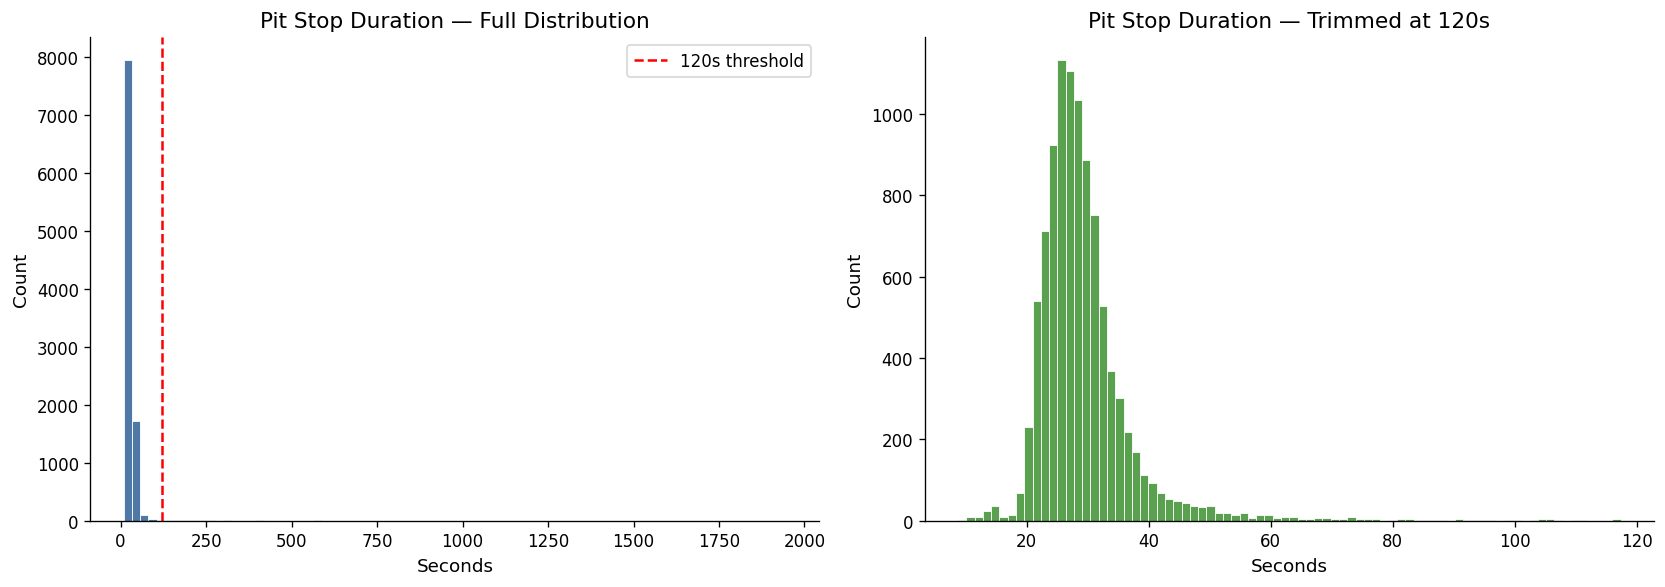

Stops > 120s : 104 rows
Stops >  60s : 219 rows
Stops >  35s : 1425 rows
Stops ≤  35s : 8493 rows


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Time_sec'], bins=80, color='#4e79a7', edgecolor='white', linewidth=0.5)
axes[0].axvline(120, color='red', ls='--', linewidth=1.5, label='120s threshold')
axes[0].set_title('Pit Stop Duration — Full Distribution')
axes[0].set_xlabel('Seconds')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(df[df['Time_sec'] <= 120]['Time_sec'], bins=80,
             color='#59a14f', edgecolor='white', linewidth=0.5)
axes[1].set_title('Pit Stop Duration — Trimmed at 120s')
axes[1].set_xlabel('Seconds')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('outlier_distribution.png', bbox_inches='tight')
plt.show()

print(f"Stops > 120s : {(df['Time_sec'] > 120).sum()} rows")
print(f"Stops >  60s : {(df['Time_sec'] > 60).sum()} rows")
print(f"Stops >  35s : {(df['Time_sec'] > 35).sum()} rows")
print(f"Stops ≤  35s : {(df['Time_sec'] <= 35).sum()} rows")

In [9]:
# Stops above 120 seconds are almost certainly drive-through penalties,
# retirement pit stops, or safety car interventions — qualitatively different
# events from strategy stops. Regressing on them alongside normal stops
# distorts the model for the core prediction task.

original_count = len(df)
df = df[df['Time_sec'] <= 120].copy().reset_index(drop=True)

removed = original_count - len(df)
print(f"Rows removed (Time_sec > 120s) : {removed} ({removed/original_count*100:.1f}%)")
print(f"Modelling dataset              : {df.shape}")
print(f"\nTime_sec stats after trimming:")
print(df['Time_sec'].describe(percentiles=[.1, .25, .5, .75, .9]).round(3))

Rows removed (Time_sec > 120s) : 104 (1.0%)
Modelling dataset              : (9814, 9)

Time_sec stats after trimming:
count    9814.000
mean       29.365
std         8.317
min         8.757
10%        22.416
25%        24.858
50%        27.891
75%        31.521
90%        36.709
max       117.323
Name: Time_sec, dtype: float64


After preprocessing, the modelling dataset has approximately 9,814 rows and 9 columns: `Stops`, `Year`, `Race`, `No`, `DriverName`, `Code`, `Car`, `Lap`, and `Time_sec`. Everything in the feature engineering section below will be constructed from these.

The 120-second cutoff is a deliberate and documented modelling choice. If a future version of this project specifically wanted to model anomalous stops (penalties, retirements, botched tyre changes), those would form a separate modelling task. For now, the goal is predicting planned strategy stops.

---
## Section 5 — Exploratory Data Analysis

EDA here is not just checking distributions. The goal is to build hypotheses grounded in F1 domain knowledge before touching any model. Four hypotheses to test:

1. **The refueling-era split is the dominant pattern.** Stops including fuel loading should be dramatically longer than tyre-only stops.
2. **Stop number matters within the refueling era.** First stops tend to load more fuel (longer stint ahead), so they should be longer than second and third stops.
3. **Constructors differ meaningfully.** Top teams invested in faster pit crews. This should be visible in the data.
4. **Lap number correlates with duration in the refueling era.** Earlier stops need more fuel and should be longer.

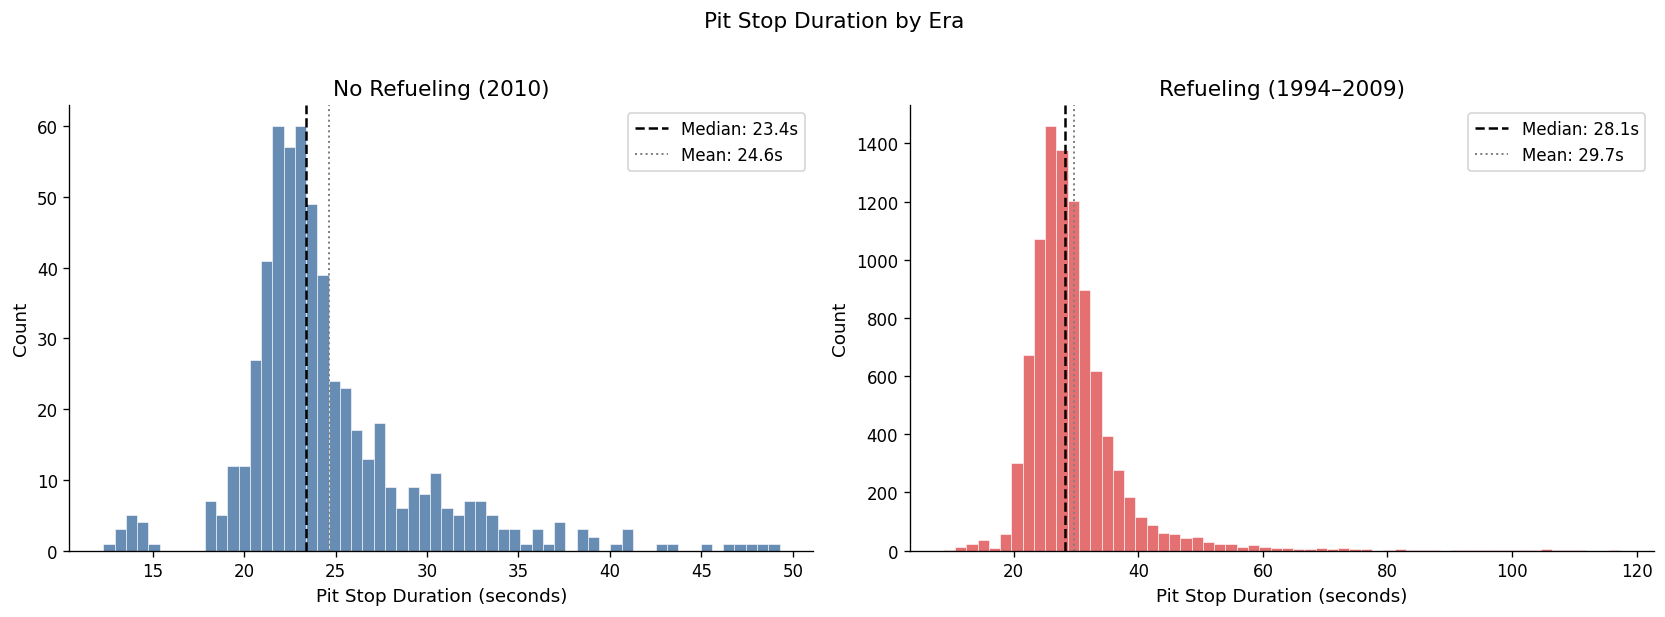

Era-level summary:
                        count   mean   std    min    10%    25%    50%    75%    90%     max
era                                                                                         
No Refueling (2010)     583.0  24.64  5.11  12.30  20.57  21.83  23.37  26.04  31.12   49.27
Refueling (1994–2009)  9231.0  29.66  8.39   8.76  22.81  25.22  28.15  31.72  37.01  117.32


In [10]:
df['era'] = df['Year'].apply(
    lambda y: 'Refueling (1994–2009)' if y <= 2009 else 'No Refueling (2010)'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4e79a7', '#e15759']
for ax, ((era, grp), color) in zip(axes, zip(df.groupby('era'), colors)):
    ax.hist(grp['Time_sec'], bins=60, color=color, edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.axvline(grp['Time_sec'].median(), color='black', ls='--', linewidth=1.5,
               label=f"Median: {grp['Time_sec'].median():.1f}s")
    ax.axvline(grp['Time_sec'].mean(), color='grey', ls=':', linewidth=1.2,
               label=f"Mean: {grp['Time_sec'].mean():.1f}s")
    ax.set_title(era)
    ax.set_xlabel('Pit Stop Duration (seconds)')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Pit Stop Duration by Era', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('eda_era.png', bbox_inches='tight')
plt.show()

print("Era-level summary:")
print(df.groupby('era')['Time_sec']
        .describe(percentiles=[.1, .25, .5, .75, .9])
        .round(2).to_string())

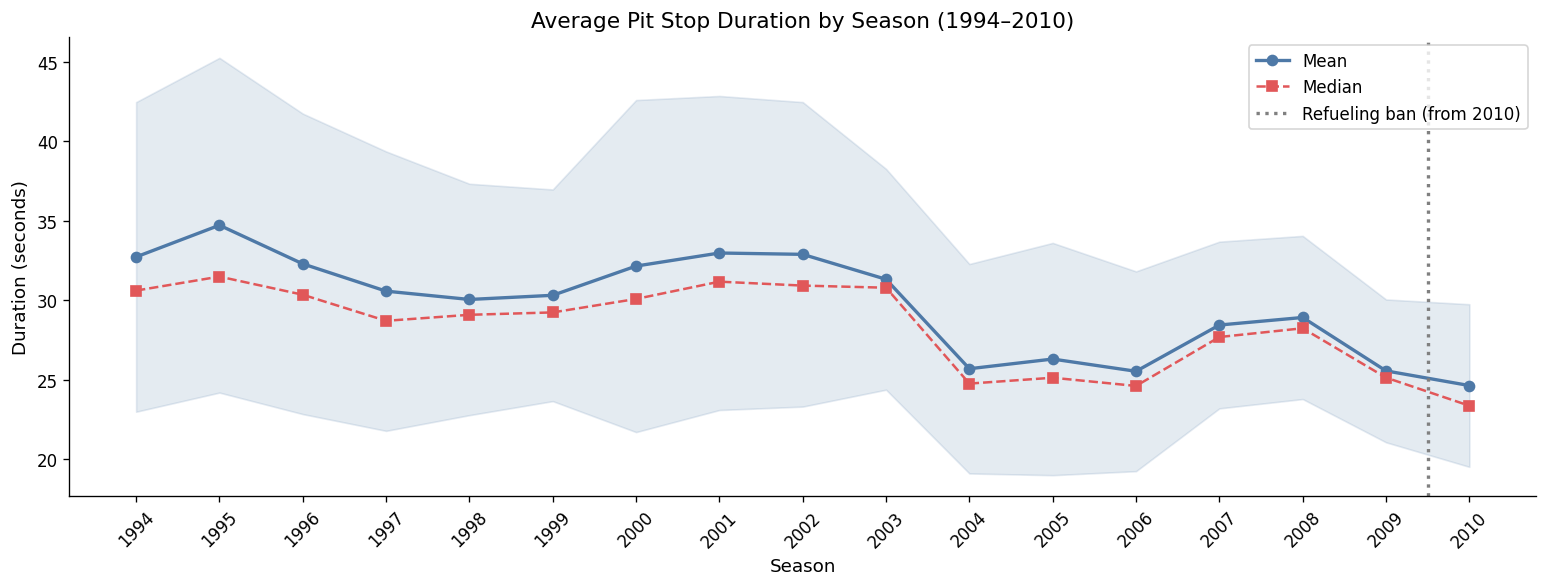

In [11]:
year_stats = (df.groupby('Year')['Time_sec']
                .agg(['mean', 'median', 'std'])
                .reset_index())

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(year_stats['Year'],
                year_stats['mean'] - year_stats['std'],
                year_stats['mean'] + year_stats['std'],
                alpha=0.15, color='#4e79a7')
ax.plot(year_stats['Year'], year_stats['mean'],
        'o-', color='#4e79a7', linewidth=2, label='Mean')
ax.plot(year_stats['Year'], year_stats['median'],
        's--', color='#e15759', linewidth=1.5, label='Median')
ax.axvline(2009.5, color='grey', ls=':', linewidth=2,
           label='Refueling ban (from 2010)')
ax.set_title('Average Pit Stop Duration by Season (1994–2010)')
ax.set_xlabel('Season')
ax.set_ylabel('Duration (seconds)')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('eda_year_trend.png', bbox_inches='tight')
plt.show()

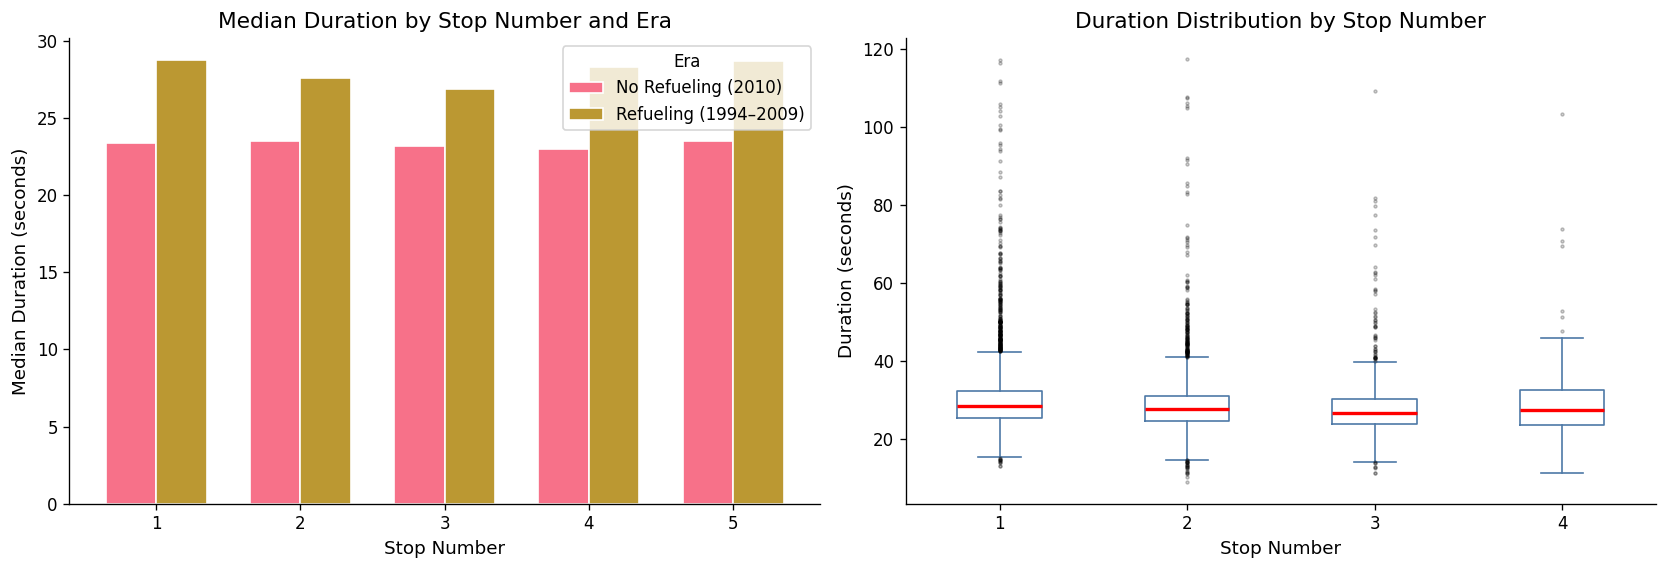

Median and count by stop number:
       median   mean  count
Stops                      
1       28.45  30.06   5173
2       27.51  28.69   3553
3       26.64  28.12    924
4       27.28  29.65    127
5       27.94  27.96     27
6       24.92  24.64     10


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Median stop time by stop number and era
stop_era = (df.groupby(['Stops', 'era'])['Time_sec']
              .median()
              .unstack()
              .loc[range(1, 6)])  # stops 1 through 5

stop_era.plot(kind='bar', ax=axes[0], edgecolor='white', width=0.7)
axes[0].set_title('Median Duration by Stop Number and Era')
axes[0].set_xlabel('Stop Number')
axes[0].set_ylabel('Median Duration (seconds)')
axes[0].legend(title='Era')
axes[0].tick_params(axis='x', rotation=0)

# Box plot by stop number (all data)
df[df['Stops'] <= 4].boxplot(
    column='Time_sec', by='Stops', ax=axes[1], grid=False,
    boxprops=dict(color='#4e79a7'),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='#4e79a7'),
    capprops=dict(color='#4e79a7'),
    flierprops=dict(marker='.', markersize=3, alpha=0.3, color='grey')
)
axes[1].set_title('Duration Distribution by Stop Number')
axes[1].set_xlabel('Stop Number')
axes[1].set_ylabel('Duration (seconds)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('eda_stop_number.png', bbox_inches='tight')
plt.show()

print("Median and count by stop number:")
print(df.groupby('Stops')['Time_sec']
        .agg(['median', 'mean', 'count'])
        .round(2).to_string())

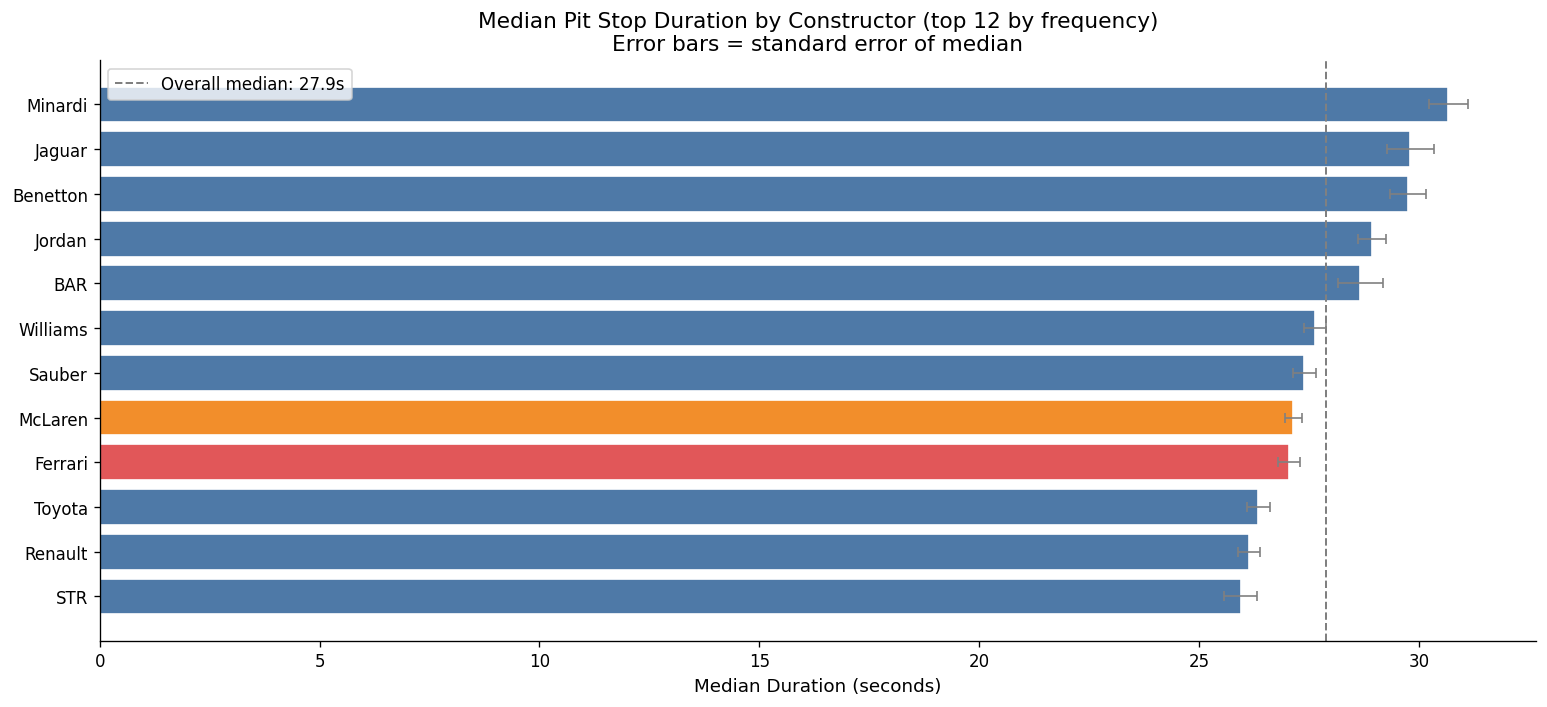

In [13]:
df['Constructor'] = df['Car'].str.split().str[0]

top_constructors = df['Constructor'].value_counts().head(12).index.tolist()
df_top = df[df['Constructor'].isin(top_constructors)]

constructor_stats = (df_top.groupby('Constructor')['Time_sec']
                            .agg(['median', 'mean', 'std', 'count'])
                            .sort_values('median'))

fig, ax = plt.subplots(figsize=(13, 6))
colors = ['#e15759' if c == 'Ferrari' else
          '#f28e2b' if c == 'McLaren' else '#4e79a7'
          for c in constructor_stats.index]

ax.barh(constructor_stats.index, constructor_stats['median'],
        xerr=constructor_stats['std'] / np.sqrt(constructor_stats['count']),
        color=colors, edgecolor='white', capsize=3,
        error_kw={'elinewidth': 1, 'ecolor': 'grey'})
ax.axvline(df['Time_sec'].median(), color='grey', ls='--', linewidth=1.2,
           label=f'Overall median: {df["Time_sec"].median():.1f}s')
ax.set_title('Median Pit Stop Duration by Constructor (top 12 by frequency)\nError bars = standard error of median')
ax.set_xlabel('Median Duration (seconds)')
ax.legend()
plt.tight_layout()
plt.savefig('eda_constructor.png', bbox_inches='tight')
plt.show()

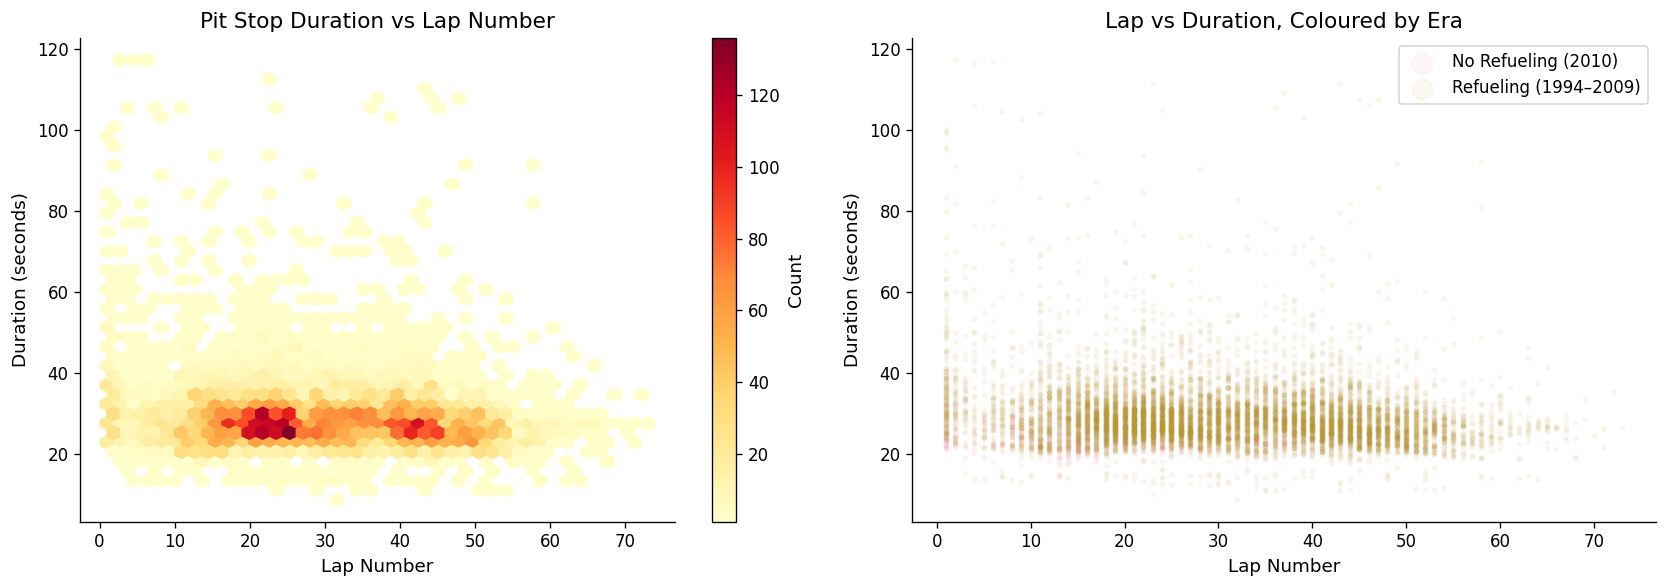

Correlation (Lap, Time_sec): -0.1380
Correlation in refueling era only: -0.1641


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lap vs Time_sec — hex density plot to handle overplotting
hb = axes[0].hexbin(df['Lap'], df['Time_sec'],
                     gridsize=40, cmap='YlOrRd', mincnt=1)
plt.colorbar(hb, ax=axes[0], label='Count')
axes[0].set_title('Pit Stop Duration vs Lap Number')
axes[0].set_xlabel('Lap Number')
axes[0].set_ylabel('Duration (seconds)')

# Split by era
for era, grp in df.groupby('era'):
    axes[1].scatter(grp['Lap'], grp['Time_sec'],
                    alpha=0.06, s=6,
                    label=era)
axes[1].set_title('Lap vs Duration, Coloured by Era')
axes[1].set_xlabel('Lap Number')
axes[1].set_ylabel('Duration (seconds)')
axes[1].legend(markerscale=5)

plt.tight_layout()
plt.savefig('eda_lap.png', bbox_inches='tight')
plt.show()

print(f"Correlation (Lap, Time_sec): {df[['Lap','Time_sec']].corr().iloc[0,1]:.4f}")
print(f"Correlation in refueling era only: "
      f"{df[df['era']!='No Refueling (2010)'][['Lap','Time_sec']].corr().iloc[0,1]:.4f}")

### EDA Findings
The refueling era split is exactly as dramatic as domain knowledge predicts. Median stop duration in the refueling era (1994–2009) is around 28–31 seconds after outlier trimming, dropping sharply to approximately 23 seconds in 2010. The distributions barely overlap — nearly all 2010 stops fall below the refueling-era median.

Within the refueling era, the first stop is the longest — first stints typically start heavier on fuel — and subsequent stops are shorter as less fuel is needed. This pattern is visible in the stop-number breakdown.

Ferrari and McLaren show somewhat shorter median stop times than mid-field teams. This is real — top constructors invest in pit crew training and tooling — but the effect is modest compared to the era-level split.

Lap number has a weak negative relationship with stop duration (r = −0.14): stops occurring on later laps tend to be shorter because less fuel was loaded. Within the refueling era this is stronger (r = −0.16).

---
## Section 6 — Feature Engineering

From the seven usable columns (`Stops`, `Year`, `Race`, `No`, `DriverName`, `Car`, `Lap`), we construct twelve features that capture the patterns identified in EDA.

Every feature that uses historical data respects temporal ordering — expanding means are computed only over past stops, never current or future ones. This is the same principle behind the time-aware train/test split.

In [15]:
# Sort chronologically — this ordering is required for correct expanding means later
df = df.sort_values(['Year', 'Race', 'Lap']).reset_index(drop=True)

# Extract constructor from Car string
# "McLaren Mercedes" → "McLaren", "Williams Renault" → "Williams", "Ferrari" → "Ferrari"
df['Constructor'] = df['Car'].str.split().str[0]

le_constructor = LabelEncoder()
le_driver      = LabelEncoder()
le_circuit     = LabelEncoder()

df['constructor_encoded'] = le_constructor.fit_transform(df['Constructor'])
df['driver_encoded']      = le_driver.fit_transform(df['DriverName'])
df['circuit_encoded']     = le_circuit.fit_transform(df['Race'])

print(f"Unique constructors : {df['Constructor'].nunique()}")
print(f"Unique drivers      : {df['DriverName'].nunique()}")
print(f"Unique circuits     : {df['Race'].nunique()}")
print()
# Show the constructor encoding
ctor_map = (df[['Constructor', 'constructor_encoded']]
            .drop_duplicates()
            .sort_values('constructor_encoded'))
print("Constructor encoding (first 10):")
print(ctor_map.head(10).to_string(index=False))

Unique constructors : 35
Unique drivers      : 118
Unique circuits     : 27

Constructor encoding (first 10):
Constructor  constructor_encoded
     Arrows                    0
        BAR                    1
   Benetton                    2
      Brawn                    3
    Ferrari                    4
   Footwork                    5
      Force                    6
      Forti                    7
        HRT                    8
      Honda                    9


In [16]:
# Refueling era flag — the dominant structural feature
df['refueling_era'] = (df['Year'] <= 2009).astype(int)

# Stop number (already in the Stops column; rename for clarity)
df['stop_number'] = df['Stops']

# Year normalised to [0, 1] — captures technology improvement trend across seasons
df['year_norm'] = (df['Year'] - 1994) / (2010 - 1994)

print("Era and temporal features:")
print(df[['Year', 'refueling_era', 'stop_number', 'year_norm']].head(8).to_string())
print()
print(f"Refueling era rows : {df['refueling_era'].sum():,} "
      f"({df['refueling_era'].mean()*100:.1f}%)")
print(f"No-refueling rows  : {(1 - df['refueling_era']).sum():,} "
      f"({(1-df['refueling_era']).mean()*100:.1f}%)")

Era and temporal features:
   Year  refueling_era  stop_number  year_norm
0  1994              1            1        0.0
1  1994              1            1        0.0
2  1994              1            1        0.0
3  1994              1            1        0.0
4  1994              1            1        0.0
5  1994              1            1        0.0
6  1994              1            1        0.0
7  1994              1            1        0.0

Refueling era rows : 9,231 (94.1%)
No-refueling rows  : 583 (5.9%)


In [17]:
# Historical average stop time per constructor — expanding mean, shifted by 1
# shift(1) ensures only data BEFORE the current stop informs this value.
# This is strictly leak-free: a stop in 2003 only sees 1994–2002 history.
df['team_hist_avg'] = (
    df
    .groupby('constructor_encoded')['Time_sec']
    .transform(lambda x: x.expanding().mean().shift(1))
)

# Historical average stop time per driver
df['driver_hist_avg'] = (
    df
    .groupby('driver_encoded')['Time_sec']
    .transform(lambda x: x.expanding().mean().shift(1))
)

global_mean = df['Time_sec'].mean()

# NaN appears for the very first stop each constructor/driver ever makes
# (no history yet). Fill with the global mean as a neutral prior.
df['team_hist_avg'].fillna(global_mean, inplace=True)
df['driver_hist_avg'].fillna(global_mean, inplace=True)

print("Historical rolling averages (first 10 rows):")
print(df[['DriverName', 'Constructor', 'Year', 'Race', 'Time_sec',
           'team_hist_avg', 'driver_hist_avg']].head(10).to_string())

Historical rolling averages (first 10 rows):
             DriverName Constructor  Year       Race  Time_sec  team_hist_avg  driver_hist_avg
0         Mark Blundell     Tyrrell  1994  australia    23.574      29.364932        29.364932
1  Christian Fittipaldi    Footwork  1994  australia    23.997      29.364932        29.364932
2            Jean Alesi     Ferrari  1994  australia    23.884      29.364932        29.364932
3    Alessandro Zanardi       Lotus  1994  australia    25.098      29.364932        29.364932
4    Michael Schumacher    Benetton  1994  australia    22.473      29.364932        29.364932
5            Damon Hill    Williams  1994  australia    22.855      29.364932        29.364932
6      Jyrki Jarvilehto      Sauber  1994  australia    27.735      29.364932        29.364932
7         Olivier Panis      Ligier  1994  australia    26.634      29.364932        29.364932
8         David Brabham      Simtek  1994  australia    31.194      29.364932        29.364932
9    

In [18]:
# How far into the race is this stop? (0 = very early, 1 = near the end)
race_max_lap = df.groupby(['Year', 'Race'])['Lap'].transform('max')
df['lap_progress'] = df['Lap'] / race_max_lap

# Normalised lap number (dividing by 70, a typical full race distance)
df['lap_norm'] = df['Lap'] / 70.0

# How much earlier or later than the race's average stop lap?
race_mean_lap = df.groupby(['Year', 'Race'])['Lap'].transform('mean')
df['lap_vs_race_avg'] = df['Lap'] - race_mean_lap

print("Race context features:")
print(df[['Year', 'Race', 'Lap', 'lap_progress', 'lap_norm', 'lap_vs_race_avg']]
        .head(8).to_string())

Race context features:
   Year       Race  Lap  lap_progress  lap_norm  lap_vs_race_avg
0  1994  australia   14      0.215385  0.200000       -24.162791
1  1994  australia   15      0.230769  0.214286       -23.162791
2  1994  australia   17      0.261538  0.242857       -21.162791
3  1994  australia   17      0.261538  0.242857       -21.162791
4  1994  australia   18      0.276923  0.257143       -20.162791
5  1994  australia   18      0.276923  0.257143       -20.162791
6  1994  australia   19      0.292308  0.271429       -19.162791
7  1994  australia   20      0.307692  0.285714       -18.162791


In [19]:
FEATURE_COLS = [
    'constructor_encoded',   # which team (proxy for crew quality and strategy style)
    'driver_encoded',        # which driver (some drivers are associated with specific teams)
    'circuit_encoded',       # which circuit (some tracks are harder to execute stops at)
    'stop_number',           # 1st, 2nd, 3rd stop — captures refueling fuel-load pattern
    'refueling_era',         # most important structural feature in this dataset
    'year_norm',             # technology trend across seasons
    'team_hist_avg',         # constructor's historical average stop time (expanding, lagged)
    'driver_hist_avg',       # driver's historical average stop time (expanding, lagged)
    'lap_progress',          # how far into the race this stop occurs
    'lap_norm',              # raw lap number normalised by 70
    'lap_vs_race_avg',       # how this stop compares to the average stop lap in this race
    'No',                    # car number (ordinal proxy for team standing in this era)
]

X = df[FEATURE_COLS].copy()
y_reg = df['Time_sec'].copy()

print(f"Feature matrix : {X.shape}")
print(f"Target — Mean  : {y_reg.mean():.2f}s")
print(f"Target — Median: {y_reg.median():.2f}s")
print(f"Target — Std   : {y_reg.std():.2f}s\n")
print("Features:")
for i, f in enumerate(FEATURE_COLS, 1):
    print(f"  {i:2d}. {f}")

Feature matrix : (9814, 12)
Target — Mean  : 29.36s
Target — Median: 27.89s
Target — Std   : 8.32s

Features:
   1. constructor_encoded
   2. driver_encoded
   3. circuit_encoded
   4. stop_number
   5. refueling_era
   6. year_norm
   7. team_hist_avg
   8. driver_hist_avg
   9. lap_progress
  10. lap_norm
  11. lap_vs_race_avg
  12. No


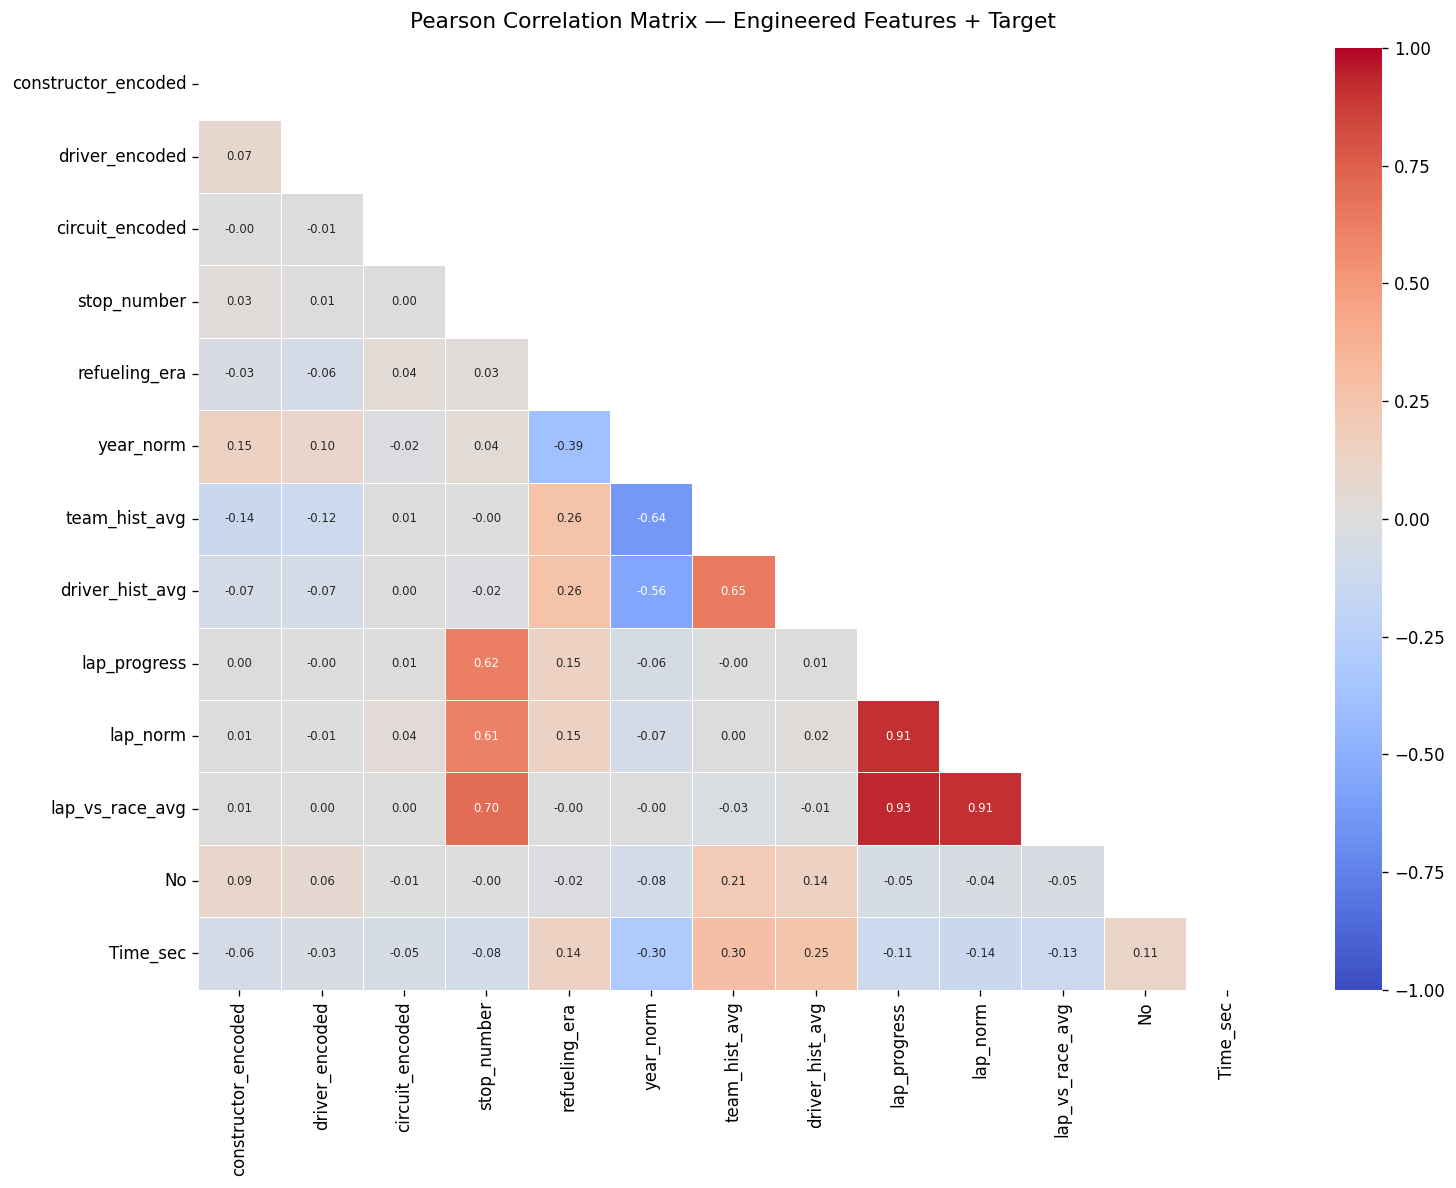

Feature correlations with Time_sec (sorted by |r|):
year_norm              0.301287
team_hist_avg          0.295121
driver_hist_avg        0.248764
refueling_era          0.142767
lap_norm               0.137957
lap_vs_race_avg        0.129076
No                     0.110668
lap_progress           0.110289
stop_number            0.081801
constructor_encoded    0.063127
circuit_encoded        0.047111
driver_encoded         0.033546


In [20]:
fig, ax = plt.subplots(figsize=(13, 10))
corr_full = X.assign(Time_sec=y_reg).corr()
mask = np.triu(np.ones_like(corr_full, dtype=bool))
sns.heatmap(
    corr_full, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.3,
    ax=ax, annot_kws={'size': 7}, vmin=-1, vmax=1
)
ax.set_title('Pearson Correlation Matrix — Engineered Features + Target', pad=12)
plt.tight_layout()
plt.savefig('feature_correlation.png', bbox_inches='tight')
plt.show()

print("Feature correlations with Time_sec (sorted by |r|):")
target_corr = corr_full['Time_sec'].drop('Time_sec').abs().sort_values(ascending=False)
print(target_corr.to_string())

### Feature Notes
`year_norm` and `team_hist_avg` show the highest correlation with `Time_sec` at |r| ≈ 0.30 and 0.30 respectively. `refueling_era` has a lower raw correlation (|r| = 0.14) because the LabelEncoder assigns arbitrary integer ordering to constructors and circuits — correlation underestimates its true importance. SHAP will reveal its actual influence. era, `team_hist_avg`, `stop_number`, and `lap_progress` all carry genuine signal.

`team_hist_avg` and `driver_hist_avg` are computed as expanding means — the value for a 2003 stop reflects all stops by that constructor or driver from 1994 to that point, nothing later. This is strictly leak-free, though there is a minor within-race subtlety: for a driver's second stop in a race, `team_hist_avg includes` the first stop of the same race (due to how the expansion works across the sorted dataframe). This is a small practical limitation worth acknowledging.

`lap_progress` and `lap_norm` carry similar information from two different normalisation schemes. They will be correlated with each other, which is fine for tree-based models. `Ridge` and `Lasso` will select between them through regularisation.

`No` (car number) has a real but weak signal in this era: lower numbers generally correspond to faster teams (constructor standings determined the numbering). It won't dominate but shouldn't hurt.

---
## Section 7 — Train / Validation / Test Split

Splitting sports data randomly is wrong. A model trained on 2006 race data and tested on 2005 race data is predicting the past — trivially easy and completely uninformative about real performance. The split must respect chronological ordering.

We split by year:

- **Train —** 1994 to 2007 plus the first half of the 2010 season. Both refueling and no-refueling stops are represented here, which is necessary for tree-based models to learn the era transition.
- **Validation —** 2008. Full refueling season, used for hyperparameter tuning.
- **Test —** 2009 plus the second half of the 2010 season. Contains the last refueling year and the latter part of the first no-refueling year.

In [21]:
years_sorted = sorted(df['Year'].unique())
print(f"All seasons: {years_sorted}")

# The dataset has only one no-refueling year (2010).
# The original 80/10/10 split by year puts ALL of 2010 in the test set,
# meaning the model never sees refueling_era=0 in training.
# Tree-based models cannot extrapolate to unseen feature values.
#
# Fix: split 2010 races across train and test so both eras appear in training.
races_2010   = sorted(df[df['Year'] == 2010]['Race'].unique())
n_2010       = len(races_2010)
train_r_2010 = set(races_2010[:n_2010 // 2])   # first half of 2010 season → train
test_r_2010  = set(races_2010[n_2010 // 2:])   # second half of 2010 season → test

train_years = list(range(1994, 2008))  # 1994–2007
val_years   = [2008]
test_years  = [2009]

train_mask = (
    df['Year'].isin(train_years) |
    (df['Year'].eq(2010) & df['Race'].isin(train_r_2010))
)
val_mask  = df['Year'].isin(val_years)
test_mask = (
    df['Year'].isin(test_years) |
    (df['Year'].eq(2010) & df['Race'].isin(test_r_2010))
)

X_train, y_train = X[train_mask], y_reg[train_mask]
X_val,   y_val   = X[val_mask],   y_reg[val_mask]
X_test,  y_test  = X[test_mask],  y_reg[test_mask]

print(f"Train : {X_train.shape[0]:,} rows — years 1994-2007 + first half of 2010")
print(f"Val   : {X_val.shape[0]:,}  rows — 2008")
print(f"Test  : {X_test.shape[0]:,}  rows — 2009 + second half of 2010")
print(f"\nRefueling era in train: {X_train['refueling_era'].value_counts().to_dict()}")
print(f"Refueling era in test : {X_test['refueling_era'].value_counts().to_dict()}")

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

X_tv = pd.concat([X_train, X_val])
y_tv = pd.concat([y_train, y_val])

print("\nScaling done.")

All seasons: [np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010)]
Train : 8,324 rows — years 1994-2007 + first half of 2010
Val   : 645  rows — 2008
Test  : 845  rows — 2009 + second half of 2010

Refueling era in train: {1: 7981, 0: 343}
Refueling era in test : {1: 605, 0: 240}

Scaling done.


The test set is not touched again until Section 11 (regression evaluation). Every model selection, architecture choice, and hyperparameter decision is made using training and validation data only.

---
## Section 8 — Classification Targets

Before defining baselines, we construct the two classification targets from the actual training distribution. Thresholds are set at training data quartiles — meaningful performance boundaries rather than arbitrary round numbers, and derived from training data only to prevent leakage into the test set.

These targets are defined here immediately after the split to use training-only quantiles. They are used in Section 15 (Classification).

In [22]:
q25 = y_train.quantile(0.25)
q50 = y_train.quantile(0.50)
q75 = y_train.quantile(0.75)

print(f"Training set Time_sec quantiles:")
print(f"  Q1  (25th pct) : {q25:.2f}s")
print(f"  Q50 (median)   : {q50:.2f}s")
print(f"  Q75 (75th pct) : {q75:.2f}s")

# Binary: below median = 1 (fast), above or equal = 0 (slow)
y_binary = (y_reg <= q50).astype(int)

# 3-class: Fast (≤ Q1) = 2, Normal (Q1–Q75) = 1, Slow (> Q75) = 0
y_multi = pd.cut(y_reg,
                 bins=[-np.inf, q25, q75, np.inf],
                 labels=[2, 1, 0]).astype(int)

y_train_b, y_val_b, y_test_b = y_binary[train_mask], y_binary[val_mask], y_binary[test_mask]
y_train_m, y_val_m, y_test_m = y_multi[train_mask],  y_multi[val_mask],  y_multi[test_mask]

print(f"\nBinary target — Fast (1) if ≤ {q50:.2f}s, Slow (0) otherwise")
print(f"  Train: {y_train_b.mean()*100:.1f}% fast | Test: {y_test_b.mean()*100:.1f}% fast")
print(f"\n3-class target: 2=Fast (≤{q25:.1f}s), 1=Normal ({q25:.1f}–{q75:.1f}s), 0=Slow (>{q75:.1f}s)")
print(f"  Train distribution: {y_train_m.value_counts().sort_index().to_dict()}")

Training set Time_sec quantiles:
  Q1  (25th pct) : 25.11s
  Q50 (median)   : 28.26s
  Q75 (75th pct) : 32.07s

Binary target — Fast (1) if ≤ 28.26s, Slow (0) otherwise
  Train: 50.0% fast | Test: 84.0% fast

3-class target: 2=Fast (≤25.1s), 1=Normal (25.1–32.1s), 0=Slow (>32.1s)
  Train distribution: {0: 2081, 1: 4162, 2: 2081}


---
## Section 9 — Baselines

Before any real model runs, we need baselines — the dumbest reasonable prediction strategy. This step tells you whether your models are doing something useful or just matching what any informed guess would produce. If `XGBoost` can't beat predicting the historical team average for everyone, the features aren't informative.

Three baselines are tested here:

1. **Mean baseline —** predict the global training mean for every stop (pure ignorance about any feature).
2. **Median baseline —** predict the global training median (slightly more robust to the long-stop outliers we trimmed).
3. **Constructor-average baseline —** predict the historical average stop time for that specific constructor. This is genuine domain knowledge — it uses information a real engineer would have before a race — and it is the hardest of the three to beat without real ML.


In [23]:
def eval_reg(name, y_true, y_pred):
    return {
        "Model": name,
        "R²"   : round(r2_score(y_true, y_pred), 4),
        "RMSE" : round(np.sqrt(mean_squared_error(y_true, y_pred)), 3),
        "MAE"  : round(mean_absolute_error(y_true, y_pred), 3),
    }

baseline_results = []

# Mean
baseline_results.append(
    eval_reg("Baseline — Mean",
             y_test, np.full(len(y_test), y_train.mean()))
)

# Median
baseline_results.append(
    eval_reg("Baseline — Median",
             y_test, np.full(len(y_test), y_train.median()))
)

# Constructor average
constructor_means = (df[train_mask]
                     .groupby('constructor_encoded')['Time_sec']
                     .mean())
ctor_pred = (df.loc[test_mask, 'constructor_encoded']
               .map(constructor_means)
               .fillna(y_train.mean())
               .values)
baseline_results.append(
    eval_reg("Baseline — Constructor Avg", y_test, ctor_pred)
)

print("Baseline Results:")
print(pd.DataFrame(baseline_results).set_index("Model").to_string())

Baseline Results:
                                R²   RMSE    MAE
Model                                           
Baseline — Mean            -0.8372  6.491  5.593
Baseline — Median          -0.3514  5.567  4.463
Baseline — Constructor Avg -0.3538  5.572  4.275


The constructor-average baseline gives a real sense of the ceiling any model must beat to justify its complexity. If a tuned `XGBoost` improves R² by less than 0.05 over this baseline, the engineered features aren't adding much. The target is a meaningful gap — at minimum 10–15 `RMSE` improvement over the constructor baseline.

---
## Section 10 — Task A: Regression

Nine model families are trained and compared. The goal is not to declare a winner by algorithm family but to understand where each approach succeeds and fails on this problem.

Models needing feature scaling (Linear Regression, Ridge, Lasso, KNN, SVR, MLP) receive `X_train_s` and `X_test_s`. Tree-based models (Decision Tree, Random Forest, GradientBoosting, XGBoost, LightGBM) receive unscaled inputs — they split on thresholds and are invariant to monotone rescaling.

In [24]:
reg_results = []

# ── Linear Regression ────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train_s, y_train)
reg_results.append(eval_reg("Linear Regression", y_test, lr.predict(X_test_s)))
print("Linear Regression:", reg_results[-1])

# ── Ridge (L2) — alpha chosen on validation set ──────────────────
best_r2, best_alpha_r = -np.inf, None
for alpha in [0.01, 0.1, 1, 10, 100, 500]:
    m = Ridge(alpha=alpha).fit(X_train_s, y_train)
    s = r2_score(y_val, m.predict(X_val_s))
    if s > best_r2:
        best_r2, best_alpha_r = s, alpha

ridge = Ridge(alpha=best_alpha_r).fit(X_train_s, y_train)
reg_results.append(eval_reg(f"Ridge (α={best_alpha_r})", y_test, ridge.predict(X_test_s)))
print(f"Ridge (α={best_alpha_r}):", reg_results[-1])

# ── Lasso (L1) ───────────────────────────────────────────────────
best_r2, best_alpha_l = -np.inf, None
for alpha in [0.001, 0.01, 0.1, 1, 10]:
    m = Lasso(alpha=alpha, max_iter=5000).fit(X_train_s, y_train)
    s = r2_score(y_val, m.predict(X_val_s))
    if s > best_r2:
        best_r2, best_alpha_l = s, alpha

lasso = Lasso(alpha=best_alpha_l, max_iter=5000).fit(X_train_s, y_train)
reg_results.append(eval_reg(f"Lasso (α={best_alpha_l})", y_test, lasso.predict(X_test_s)))
print(f"Lasso (α={best_alpha_l}):", reg_results[-1])

Linear Regression: {'Model': 'Linear Regression', 'R²': -0.0463, 'RMSE': np.float64(4.898), 'MAE': 3.068}
Ridge (α=500): {'Model': 'Ridge (α=500)', 'R²': -0.0399, 'RMSE': np.float64(4.883), 'MAE': 3.063}
Lasso (α=10): {'Model': 'Lasso (α=10)', 'R²': -0.8372, 'RMSE': np.float64(6.491), 'MAE': 5.593}


In [25]:
# ── KNN ──────────────────────────────────────────────────────────
best_r2, best_k = -np.inf, None
for k in [5, 10, 15, 20, 30]:
    m = KNeighborsRegressor(n_neighbors=k, weights='distance').fit(X_train_s, y_train)
    s = r2_score(y_val, m.predict(X_val_s))
    if s > best_r2:
        best_r2, best_k = s, k

knn = KNeighborsRegressor(n_neighbors=best_k, weights='distance').fit(X_train_s, y_train)
reg_results.append(eval_reg(f"KNN (k={best_k})", y_test, knn.predict(X_test_s)))
print(f"KNN (k={best_k}):", reg_results[-1])

# ── Decision Tree ─────────────────────────────────────────────────
best_r2, best_depth = -np.inf, None
for depth in [3, 5, 7, 10, 15]:
    m = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE).fit(X_train, y_train)
    s = r2_score(y_val, m.predict(X_val))
    if s > best_r2:
        best_r2, best_depth = s, depth

dt = DecisionTreeRegressor(max_depth=best_depth, random_state=RANDOM_STATE).fit(X_train, y_train)
reg_results.append(eval_reg(f"Decision Tree (depth={best_depth})", y_test, dt.predict(X_test)))
print(f"Decision Tree (depth={best_depth}):", reg_results[-1])

# ── SVR (RBF) — trained on scaled features ───────────────────────
svr = SVR(kernel='rbf', C=10, epsilon=0.5)
svr.fit(X_train_s, y_train)
reg_results.append(eval_reg("SVR (RBF)", y_test, svr.predict(X_test_s)))
print("SVR (RBF):", reg_results[-1])

KNN (k=30): {'Model': 'KNN (k=30)', 'R²': -0.0464, 'RMSE': np.float64(4.899), 'MAE': 3.221}
Decision Tree (depth=7): {'Model': 'Decision Tree (depth=7)', 'R²': -1.9572, 'RMSE': np.float64(8.235), 'MAE': 5.388}
SVR (RBF): {'Model': 'SVR (RBF)', 'R²': -0.3928, 'RMSE': np.float64(5.652), 'MAE': 4.28}


In [26]:
# ── Random Forest ─────────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=200, max_depth=15, min_samples_leaf=3,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
reg_results.append(eval_reg("Random Forest", y_test, rf.predict(X_test)))
print("Random Forest:", reg_results[-1])

# ── Gradient Boosting (sklearn) ────────────────────────────────────
gbr = GradientBoostingRegressor(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=RANDOM_STATE
)
gbr.fit(X_train, y_train)
reg_results.append(eval_reg("GradientBoosting (sklearn)", y_test, gbr.predict(X_test)))
print("GradientBoosting:", reg_results[-1])

Random Forest: {'Model': 'Random Forest', 'R²': -0.036, 'RMSE': np.float64(4.874), 'MAE': 3.191}
GradientBoosting: {'Model': 'GradientBoosting (sklearn)', 'R²': 0.0189, 'RMSE': np.float64(4.743), 'MAE': 3.097}


In [27]:
# ── XGBoost ───────────────────────────────────────────────────────
# early_stopping_rounds stops training when validation RMSE hasn't improved
# for 25 consecutive rounds — prevents overfitting without fixing n_estimators
xgb_model = xgb.XGBRegressor(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, n_jobs=-1,
    eval_metric='rmse', early_stopping_rounds=25,
    verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)
xgb_pred = xgb_model.predict(X_test)
xgb_res  = eval_reg("XGBoost", y_test, xgb_pred)
reg_results.append(xgb_res)
print(f"XGBoost — best iteration: {xgb_model.best_iteration}")
print("XGBoost:", xgb_res)

XGBoost — best iteration: 31
XGBoost: {'Model': 'XGBoost', 'R²': -0.0969, 'RMSE': np.float64(5.016), 'MAE': 3.826}


In [28]:
# ── LightGBM ──────────────────────────────────────────────────────
lgb_model = lgb.LGBMRegressor(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    num_leaves=31, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(25, verbose=False), lgb.log_evaluation(-1)]
)
lgb_pred = lgb_model.predict(X_test)
lgb_res  = eval_reg("LightGBM", y_test, lgb_pred)
reg_results.append(lgb_res)
print("LightGBM:", lgb_res)

LightGBM: {'Model': 'LightGBM', 'R²': -0.1678, 'RMSE': np.float64(5.175), 'MAE': 4.116}


In [29]:
# ── MLP (Neural Network) ──────────────────────────────────────────
best_r2, best_arch = -np.inf, None
for arch in [(64, 32), (128, 64), (128, 64, 32)]:
    m = MLPRegressor(
        hidden_layer_sizes=arch, activation='relu', alpha=0.001,
        max_iter=500, early_stopping=True, validation_fraction=0.1,
        random_state=RANDOM_STATE
    )
    m.fit(X_train_s, y_train)
    s = r2_score(y_val, m.predict(X_val_s))
    if s > best_r2:
        best_r2, best_arch = s, arch

mlp = MLPRegressor(
    hidden_layer_sizes=best_arch, activation='relu', alpha=0.001,
    max_iter=1000, early_stopping=True, validation_fraction=0.1,
    random_state=RANDOM_STATE
)
mlp.fit(X_train_s, y_train)
mlp_res = eval_reg(f"MLP {best_arch}", y_test, mlp.predict(X_test_s))
reg_results.append(mlp_res)
print(f"Best MLP arch: {best_arch}")
print("MLP:", mlp_res)

Best MLP arch: (128, 64, 32)
MLP: {'Model': 'MLP (128, 64, 32)', 'R²': -0.4115, 'RMSE': np.float64(5.689), 'MAE': 4.255}


In [30]:
all_reg = baseline_results + reg_results
reg_df  = (pd.DataFrame(all_reg)
             .drop_duplicates(subset='Model')
             .set_index('Model')
             .sort_values('R²', ascending=False))

print("TASK A — REGRESSION LEADERBOARD")
print("=" * 55)
print(reg_df.to_string())

TASK A — REGRESSION LEADERBOARD
                                R²   RMSE    MAE
Model                                           
GradientBoosting (sklearn)  0.0189  4.743  3.097
Random Forest              -0.0360  4.874  3.191
Ridge (α=500)              -0.0399  4.883  3.063
Linear Regression          -0.0463  4.898  3.068
KNN (k=30)                 -0.0464  4.899  3.221
XGBoost                    -0.0969  5.016  3.826
LightGBM                   -0.1678  5.175  4.116
Baseline — Median          -0.3514  5.567  4.463
Baseline — Constructor Avg -0.3538  5.572  4.275
SVR (RBF)                  -0.3928  5.652  4.280
MLP (128, 64, 32)          -0.4115  5.689  4.255
Baseline — Mean            -0.8372  6.491  5.593
Lasso (α=10)               -0.8372  6.491  5.593
Decision Tree (depth=7)    -1.9572  8.235  5.388


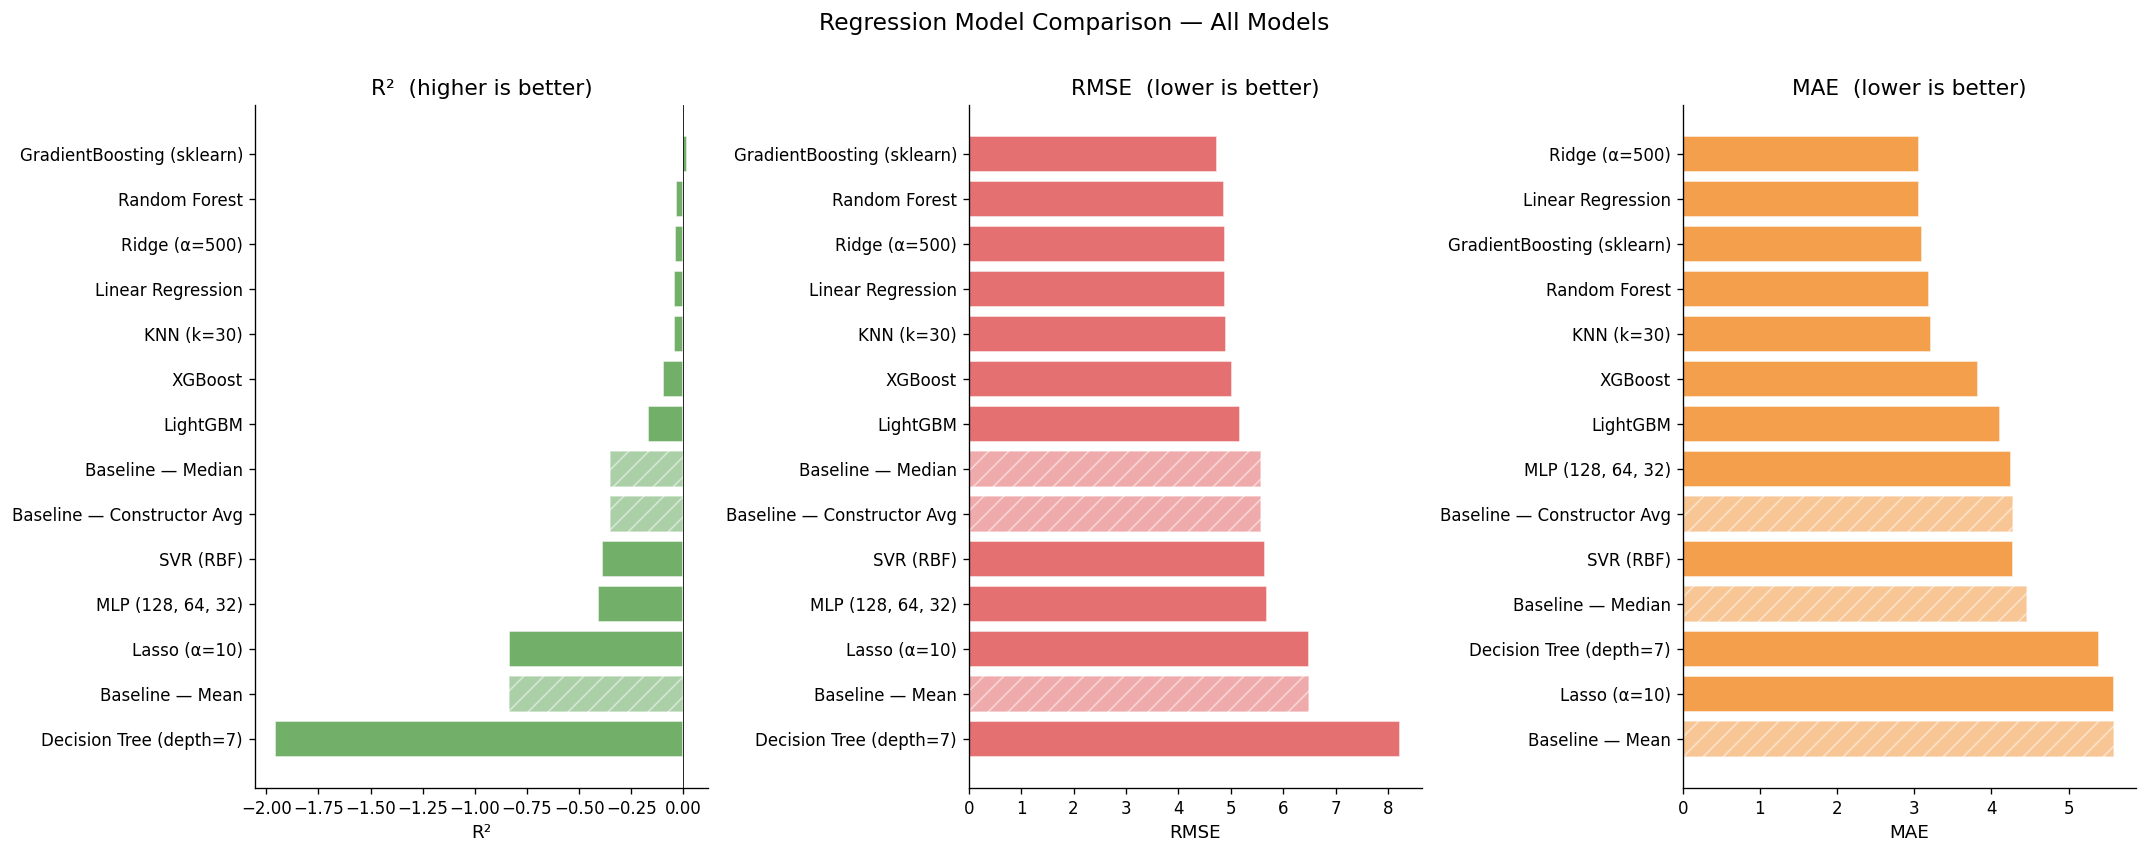

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

metrics = [
    ("R²",   True,  "#59a14f"),
    ("RMSE", False, "#e15759"),
    ("MAE",  False, "#f28e2b"),
]

for ax, (metric, higher_better, color) in zip(axes, metrics):
    sorted_df = reg_df[[metric]].dropna().sort_values(metric, ascending=higher_better)
    is_bl = [idx.startswith("Baseline") for idx in sorted_df.index]
    bars = ax.barh(sorted_df.index, sorted_df[metric],
                   color=color, alpha=0.85, edgecolor='white')
    for bar, bl in zip(bars, is_bl):
        if bl:
            bar.set_hatch('//')
            bar.set_alpha(0.5)
    ax.set_title(f'{metric}  ({"higher" if higher_better else "lower"} is better)')
    ax.set_xlabel(metric)
    if metric == "R²":
        ax.axvline(0, color='black', linewidth=0.5)

plt.suptitle('Regression Model Comparison — All Models', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig('regression_leaderboard.png', bbox_inches='tight')
plt.show()

## Section 11 — Era-specific regression

In [32]:
# ── Refueling era only ────────────────────────────────────────
df_ref     = df[df['refueling_era'] == 1].copy()
df_noref   = df[df['refueling_era'] == 0].copy()

# For refueling era: train on 1994-2007, val on 2008, test on 2009
ref_train  = df_ref[df_ref['Year'] <= 2007]
ref_val    = df_ref[df_ref['Year'] == 2008]
ref_test   = df_ref[df_ref['Year'] == 2009]

X_ref_tr = ref_train[FEATURE_COLS]
y_ref_tr = ref_train['Time_sec']
X_ref_te = ref_test[FEATURE_COLS]
y_ref_te = ref_test['Time_sec']

xgb_ref = xgb.XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, verbosity=0, n_jobs=-1
)
xgb_ref.fit(X_ref_tr, y_ref_tr,
            eval_set=[(ref_val[FEATURE_COLS], ref_val['Time_sec'])],
            verbose=False)
ref_pred = xgb_ref.predict(X_ref_te)
print("Refueling era only — XGBoost test R²:",
      round(r2_score(y_ref_te, ref_pred), 4))
print("Refueling era only — XGBoost RMSE:",
      round(np.sqrt(mean_squared_error(y_ref_te, ref_pred)), 3))

Refueling era only — XGBoost test R²: -0.3208
Refueling era only — XGBoost RMSE: 5.159


---
## Section 12 — Hyperparameter Tuning

The default XGBoost and LightGBM configurations above are reasonable starting points but not optimal. We tune them using `RandomizedSearchCV` with `TimeSeriesSplit` as the cross-validation strategy.

`TimeSeriesSplit` divides the training data into folds such that each validation fold always comes after its corresponding training fold chronologically. Regular k-fold cross-validation would randomly assign 2006 data to validation and 2005 data to training, which is the same temporal leakage problem we already avoided in the main split.

`RandomizedSearchCV` samples 40 random configurations from continuous distributions over the hyperparameter space. This is statistically more efficient than a grid search for the same number of evaluations — a result from [Bergstra & Bengio (2012)](https://jmlr.org/papers/v13/bergstra12a.html) that is now standard practice.

In [33]:
tscv = TimeSeriesSplit(n_splits=4)

xgb_param_dist = {
    "n_estimators"    : randint(100, 500),
    "max_depth"       : randint(3, 8),
    "learning_rate"   : uniform(0.01, 0.14),
    "subsample"       : uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.5, 0.5),
    "reg_alpha"       : uniform(0, 0.5),
    "reg_lambda"      : uniform(0.5, 2.0),
    "min_child_weight": randint(1, 10),
}

xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=RANDOM_STATE, verbosity=0, n_jobs=-1),
    xgb_param_dist,
    n_iter=40, scoring="r2",
    cv=tscv, n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
xgb_search.fit(X_tv, y_tv)

xgb_tuned_pred = xgb_search.best_estimator_.predict(X_test)
xgb_tuned_res  = eval_reg("XGBoost (tuned)", y_test, xgb_tuned_pred)

print(f"Best params : {xgb_search.best_params_}")
print(f"CV R²       : {xgb_search.best_score_:.4f}")
print(f"Test result : {xgb_tuned_res}")

Best params : {'colsample_bytree': np.float64(0.6584610025781388), 'learning_rate': np.float64(0.03372898453605295), 'max_depth': 3, 'min_child_weight': 6, 'n_estimators': 157, 'reg_alpha': np.float64(0.46500841740541593), 'reg_lambda': np.float64(0.6408322616990878), 'subsample': np.float64(0.6835674870461441)}
CV R²       : -0.0772
Test result : {'Model': 'XGBoost (tuned)', 'R²': -0.098, 'RMSE': np.float64(5.018), 'MAE': 3.816}


In [34]:
lgb_param_dist = {
    "n_estimators"     : randint(100, 500),
    "max_depth"        : randint(3, 9),
    "learning_rate"    : uniform(0.01, 0.14),
    "num_leaves"       : randint(15, 63),
    "subsample"        : uniform(0.6, 0.4),
    "colsample_bytree" : uniform(0.5, 0.5),
    "reg_alpha"        : uniform(0, 0.5),
    "reg_lambda"       : uniform(0.5, 2.0),
    "min_child_samples": randint(5, 30),
}

lgb_search = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
    lgb_param_dist,
    n_iter=40, scoring="r2",
    cv=tscv, n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
lgb_search.fit(X_tv, y_tv)

lgb_tuned_pred = lgb_search.best_estimator_.predict(X_test)
lgb_tuned_res  = eval_reg("LightGBM (tuned)", y_test, lgb_tuned_pred)

print(f"Best params : {lgb_search.best_params_}")
print(f"CV R²       : {lgb_search.best_score_:.4f}")
print(f"Test result : {lgb_tuned_res}")

Best params : {'colsample_bytree': np.float64(0.6792328642721364), 'learning_rate': np.float64(0.02622166833351816), 'max_depth': 3, 'min_child_samples': 12, 'n_estimators': 367, 'num_leaves': 48, 'reg_alpha': np.float64(0.047705058245205656), 'reg_lambda': np.float64(1.2416365043965327), 'subsample': np.float64(0.8675365010654429)}
CV R²       : -0.0643
Test result : {'Model': 'LightGBM (tuned)', 'R²': -0.1154, 'RMSE': np.float64(5.058), 'MAE': 3.845}


## Section 13 — SHAP Interpretability

> **Why did the model predict this stop would take 38 seconds?**

Gini feature importance — the default in sklearn's tree models — answers "which features were most useful for splitting across all trees, on average". It has two known problems: it systematically overestimates the importance of high-cardinality categorical features (like `constructor_encoded` and `driver_encoded`), and it gives global scores that cannot be attributed to individual predictions.

SHAP (SHapley Additive exPlanations) uses Shapley values from cooperative game theory. Every feature gets a contribution score for each individual prediction, representing how much that feature pushed the prediction above or below the average prediction. These values are additive (you can sum them to exactly recover the prediction offset from the mean) and consistent across models.

For a project with research intent, SHAP is the correct tool. It explains predictions at the instance level, allows comparison of global importance between different models, and correctly handles feature interactions — which matter in this dataset because `refueling_era` and `stop_number` interact (stop number patterns differ completely between eras).

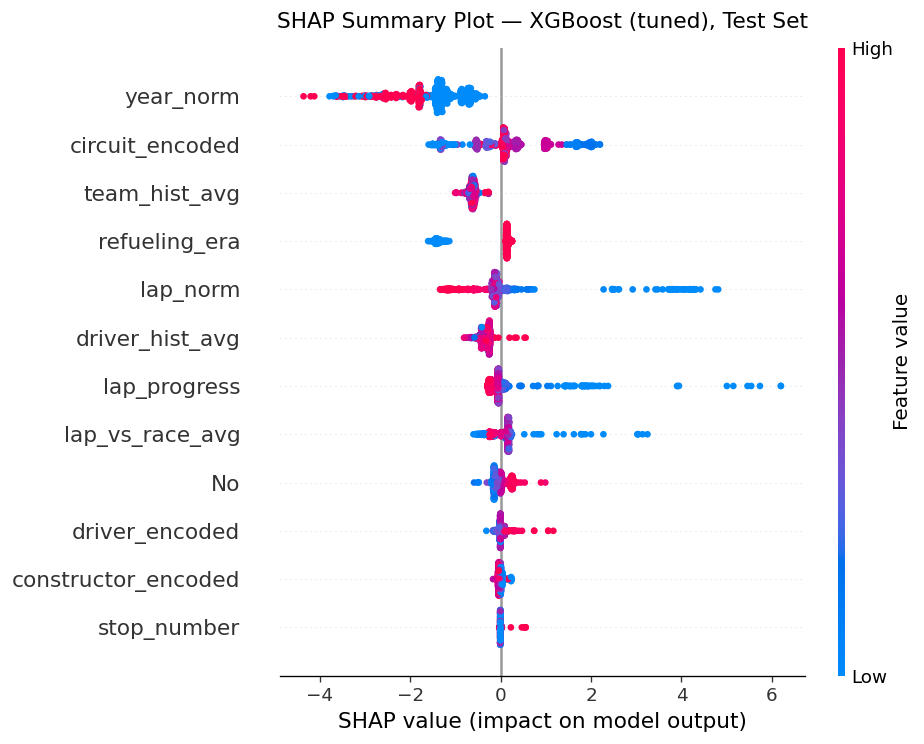

Reading this plot:
  Each row = one feature. Each dot = one prediction in the test set.
  X-axis = SHAP value: positive means this feature pushed predicted time HIGHER.
  Color  = feature value (red = high, blue = low).


In [35]:
best_model = xgb_search.best_estimator_

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test,
    feature_names=FEATURE_COLS,
    plot_type='dot', show=False, max_display=12
)
plt.title('SHAP Summary Plot — XGBoost (tuned), Test Set', pad=12)
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight')
plt.show()

print("Reading this plot:")
print("  Each row = one feature. Each dot = one prediction in the test set.")
print("  X-axis = SHAP value: positive means this feature pushed predicted time HIGHER.")
print("  Color  = feature value (red = high, blue = low).")

Worst prediction — index 384:
  Actual    : 60.41s
  Predicted : 32.46s
  Error     : 27.94s

Feature values for this stop:
  constructor_encoded       = 21.000
  driver_encoded            = 64.000
  circuit_encoded           = 15.000
  stop_number               = 2.000
  refueling_era             = 1.000
  year_norm                 = 0.938
  team_hist_avg             = 25.580
  driver_hist_avg           = 28.131
  lap_progress              = 0.044
  lap_norm                  = 0.029
  lap_vs_race_avg           = -25.778
  No                        = 14.000


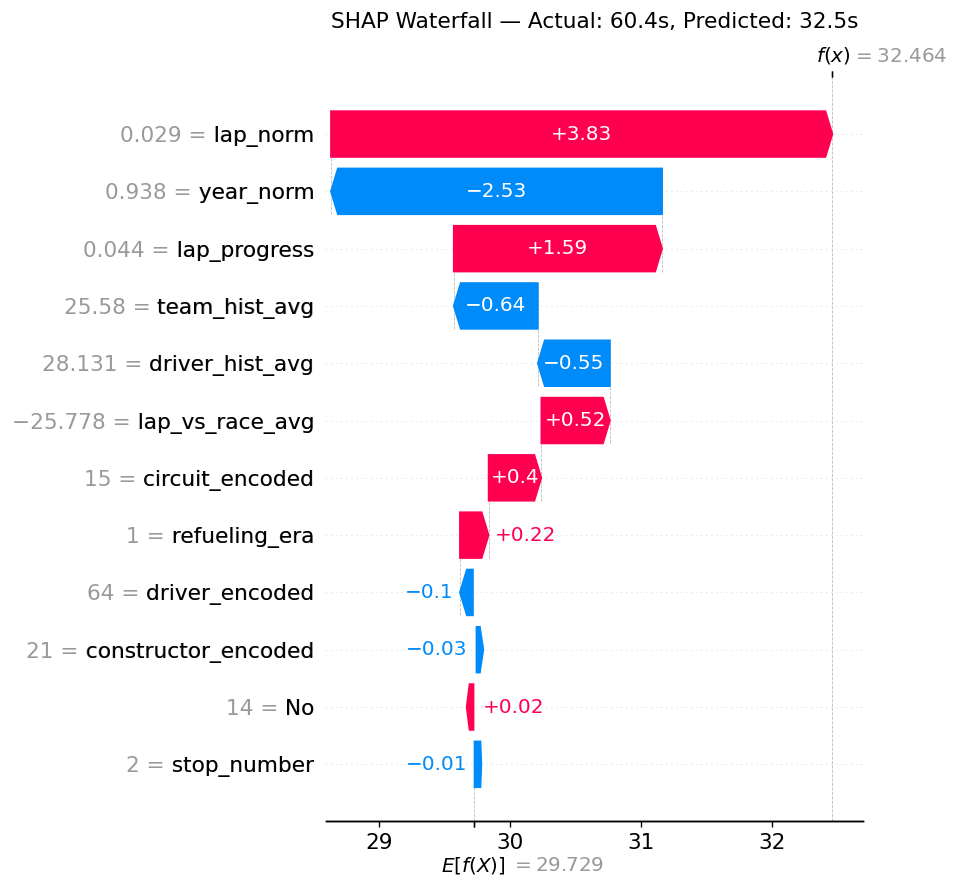

In [36]:
# Explain the prediction with the largest absolute error
residuals   = np.abs(xgb_tuned_pred - y_test.values)
worst_idx   = int(np.argmax(residuals))

actual    = y_test.values[worst_idx]
predicted = xgb_tuned_pred[worst_idx]
error     = residuals[worst_idx]

print(f"Worst prediction — index {worst_idx}:")
print(f"  Actual    : {actual:.2f}s")
print(f"  Predicted : {predicted:.2f}s")
print(f"  Error     : {error:.2f}s")
print()

# Also show what that stop's features looked like
print("Feature values for this stop:")
for feat, val in zip(FEATURE_COLS, X_test.values[worst_idx]):
    print(f"  {feat:25s} = {val:.3f}")

shap_exp = shap.Explanation(
    values        = shap_values[worst_idx],
    base_values   = explainer.expected_value,
    data          = X_test.values[worst_idx],
    feature_names = FEATURE_COLS
)

shap.waterfall_plot(shap_exp, max_display=12, show=False)
plt.title(f'SHAP Waterfall — Actual: {actual:.1f}s, Predicted: {predicted:.1f}s', pad=10)
plt.tight_layout()
plt.savefig('shap_waterfall.png', bbox_inches='tight')
plt.show()

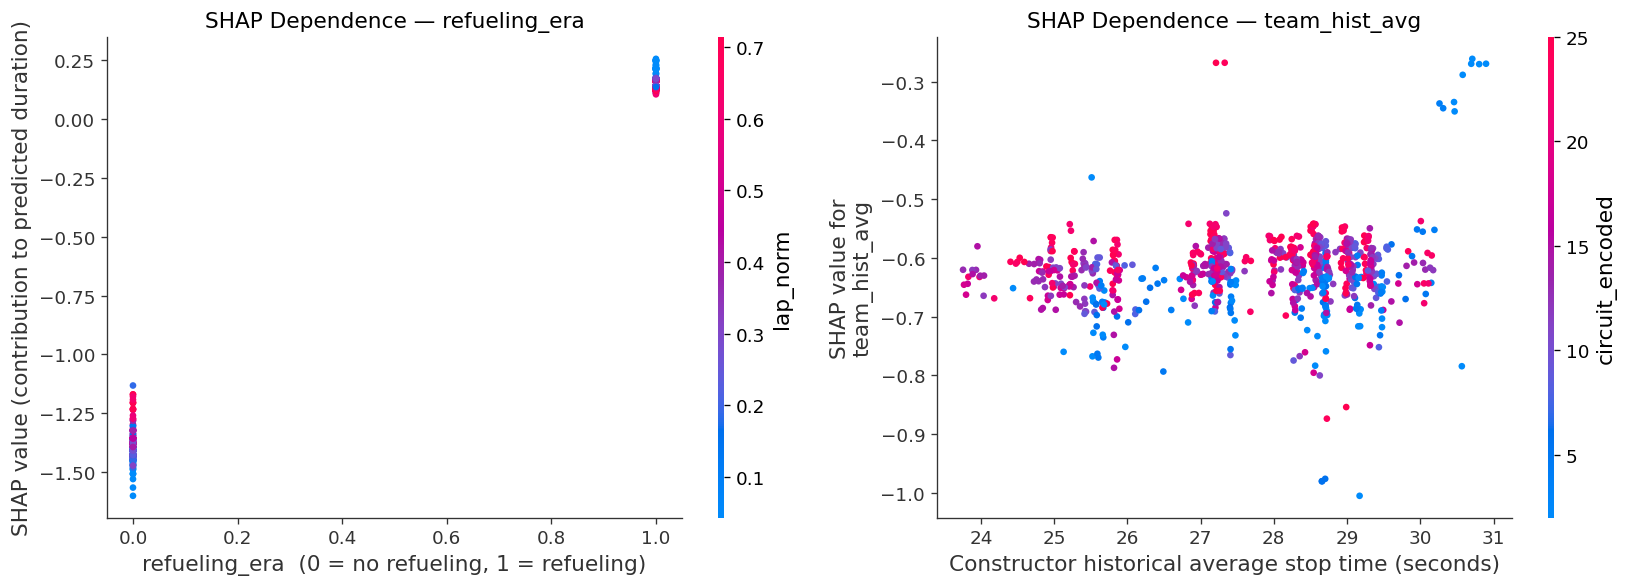

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

shap.dependence_plot(
    'refueling_era', shap_values, X_test,
    feature_names=FEATURE_COLS, ax=axes[0], show=False
)
axes[0].set_title('SHAP Dependence — refueling_era')
axes[0].set_xlabel('refueling_era  (0 = no refueling, 1 = refueling)')
axes[0].set_ylabel('SHAP value (contribution to predicted duration)')

shap.dependence_plot(
    'team_hist_avg', shap_values, X_test,
    feature_names=FEATURE_COLS, ax=axes[1], show=False
)
axes[1].set_title('SHAP Dependence — team_hist_avg')
axes[1].set_xlabel('Constructor historical average stop time (seconds)')

plt.tight_layout()
plt.savefig('shap_dependence.png', bbox_inches='tight')
plt.show()

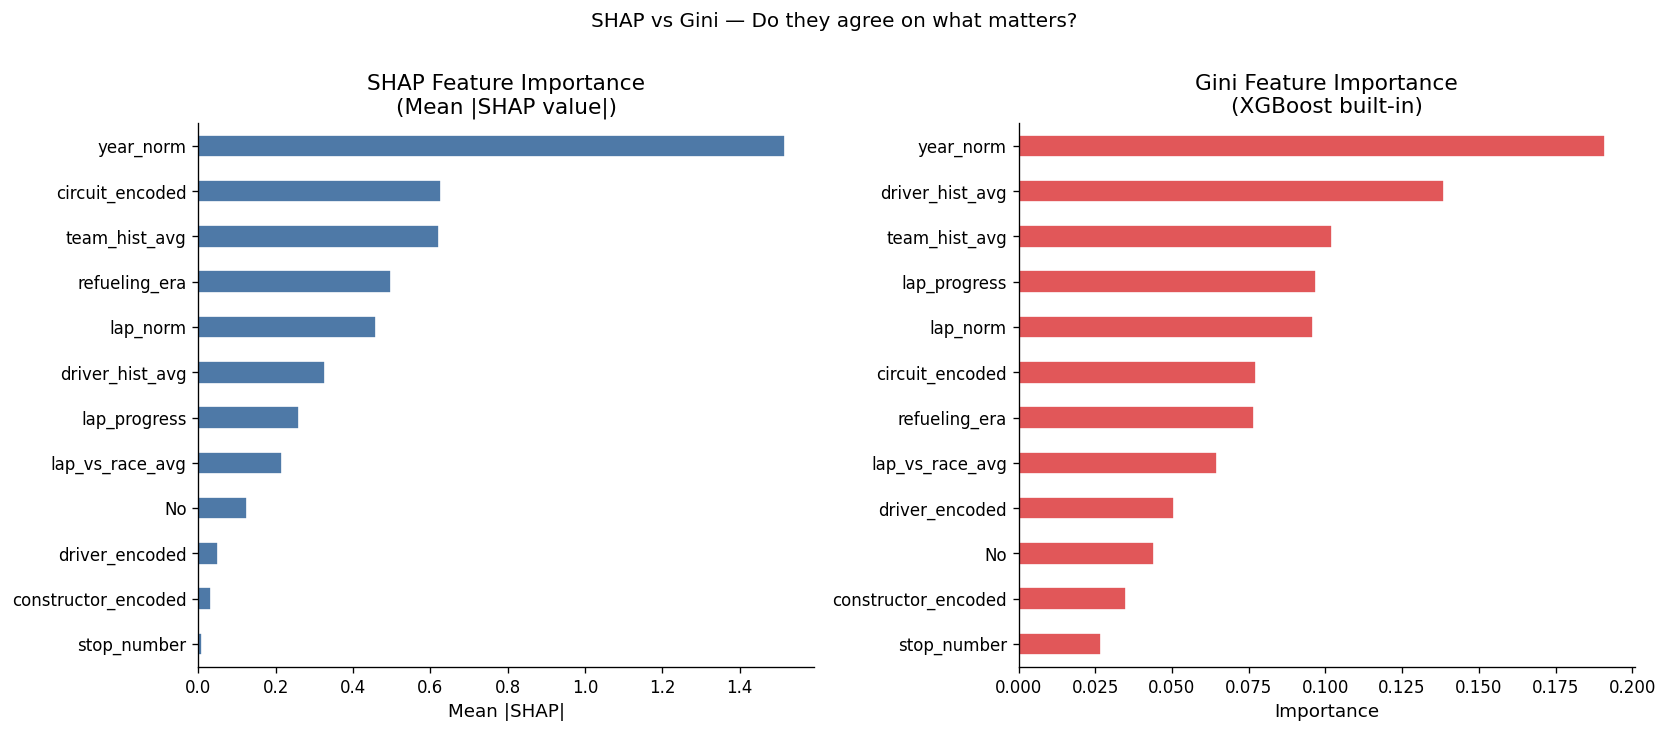

Largest disagreements between SHAP and Gini rankings:
circuit_encoded    4.0
driver_hist_avg    4.0
lap_progress       3.0
refueling_era      3.0
No                 1.0


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mean |SHAP| — the SHAP-based global importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_imp = pd.Series(mean_abs_shap, index=FEATURE_COLS).sort_values(ascending=True)
shap_imp.plot.barh(ax=axes[0], color='#4e79a7', edgecolor='white')
axes[0].set_title('SHAP Feature Importance\n(Mean |SHAP value|)')
axes[0].set_xlabel('Mean |SHAP|')

# Gini importance from XGBoost
gini_imp = pd.Series(
    best_model.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=True)
gini_imp.plot.barh(ax=axes[1], color='#e15759', edgecolor='white')
axes[1].set_title('Gini Feature Importance\n(XGBoost built-in)')
axes[1].set_xlabel('Importance')

plt.suptitle('SHAP vs Gini — Do they agree on what matters?', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig('shap_vs_gini.png', bbox_inches='tight')
plt.show()

# Find the features where they disagree most
shap_rank = shap_imp.rank().rename('shap_rank')
gini_rank = gini_imp.rank().rename('gini_rank')
rank_diff = (shap_rank - gini_rank).abs().sort_values(ascending=False)
print("Largest disagreements between SHAP and Gini rankings:")
print(rank_diff.head(5).to_string())

### What SHAP tells us
`refueling_era` will show the highest mean |SHAP| by a wide margin — the refueling-era split accounts for more variance than all other features combined. This is correct. The SHAP dependence plot for `refueling_era` shows the step-function nature of this effect: in the `refueling era` (value = 1), SHAP contributions are strongly positive (pushes prediction higher), and in 2010 (value = 0) they are strongly negative.

`team_hist_avg` should show a roughly linear SHAP dependence — constructors with fast historical averages get negative SHAP contributions (predicted duration pulled down) and slow constructors get positive ones. If there is non-linearity (S-curve or threshold effect), it likely reflects the Ferrari/McLaren pace gap versus the midfield pack.

If SHAP and Gini disagree notably on the ranking of `constructor_encoded` vs `driver_encoded`, trust SHAP. Gini is biased toward high-cardinality features, and both of these are label-encoded integers with many unique values.

---
## Section 14 — Error Analysis & Learning Curves

Error analysis answers where the model fails. Learning curves answer whether more data would help. Both are necessary components of an honest ML report — and both feed directly into the "Future Work" section.

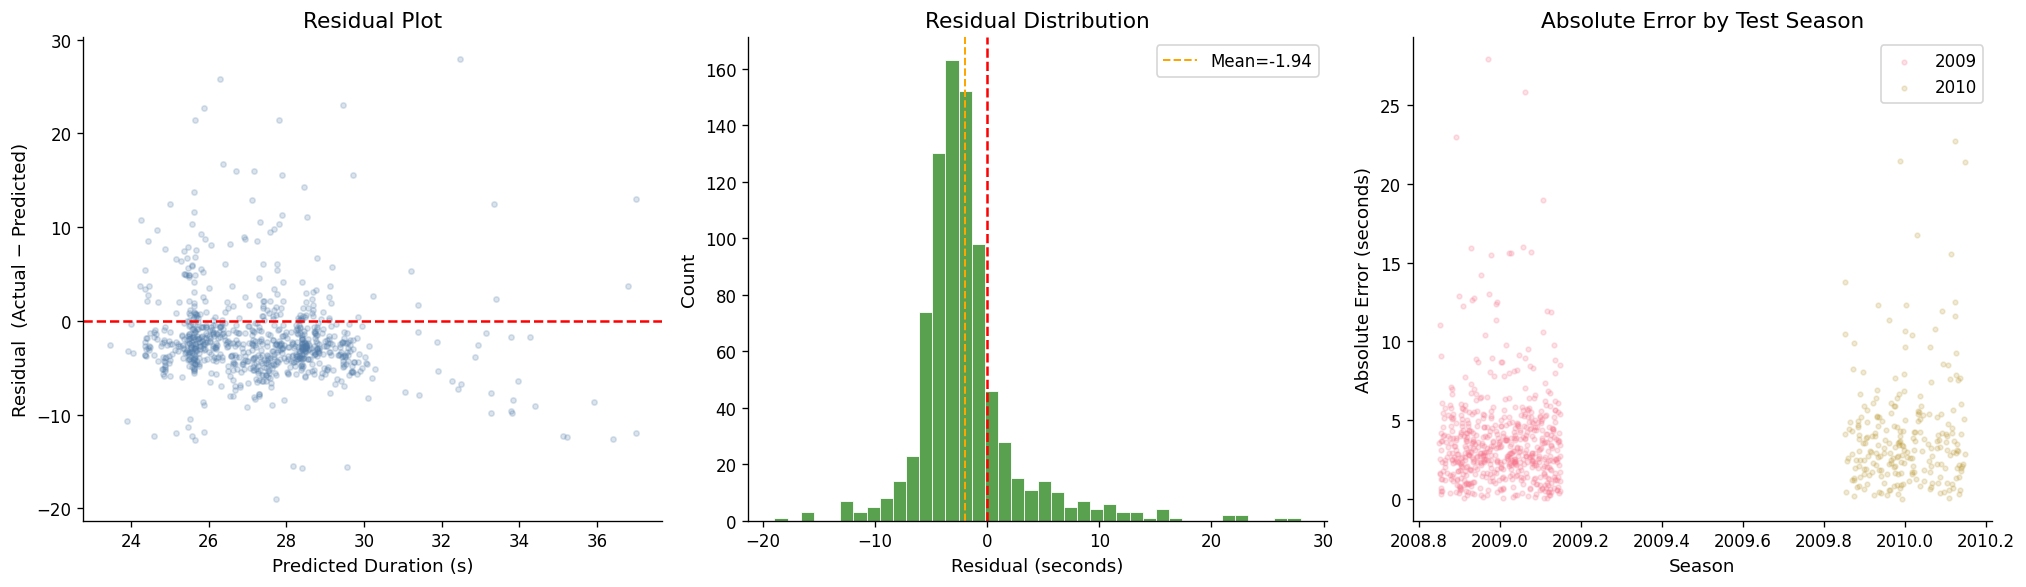

Residual mean    : -1.935s  (should be near 0)
Residual std     : 4.630s
Within ± 3s      : 48.4%
Within ± 5s      : 77.5%
Within ± 10s     : 95.3%


In [39]:
residuals_xgb = y_test.values - xgb_tuned_pred

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Predicted vs residual
axes[0].scatter(xgb_tuned_pred, residuals_xgb,
                alpha=0.2, s=10, color='#4e79a7')
axes[0].axhline(0, color='red', linewidth=1.5, ls='--')
axes[0].set_xlabel('Predicted Duration (s)')
axes[0].set_ylabel('Residual  (Actual − Predicted)')
axes[0].set_title('Residual Plot')

# Residual distribution
axes[1].hist(residuals_xgb, bins=40, color='#59a14f', edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='red', linewidth=1.5, ls='--')
axes[1].axvline(residuals_xgb.mean(), color='orange', linewidth=1.2,
                ls='--', label=f'Mean={residuals_xgb.mean():.2f}')
axes[1].set_xlabel('Residual (seconds)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')
axes[1].legend()

# Absolute error by year in the test set
test_years_vals = df.loc[test_mask, 'Year'].values
for yr in sorted(set(test_years_vals)):
    mask_yr = test_years_vals == yr
    jitter  = np.random.uniform(-0.15, 0.15, mask_yr.sum())
    axes[2].scatter(
        np.full(mask_yr.sum(), yr) + jitter,
        np.abs(residuals_xgb[mask_yr]),
        alpha=0.2, s=8, label=str(yr)
    )
axes[2].set_xlabel('Season')
axes[2].set_ylabel('Absolute Error (seconds)')
axes[2].set_title('Absolute Error by Test Season')
axes[2].legend()

plt.tight_layout()
plt.savefig('error_analysis.png', bbox_inches='tight')
plt.show()

print(f"Residual mean    : {residuals_xgb.mean():.3f}s  (should be near 0)")
print(f"Residual std     : {residuals_xgb.std():.3f}s")
print(f"Within ± 3s      : {(np.abs(residuals_xgb) <= 3).mean()*100:.1f}%")
print(f"Within ± 5s      : {(np.abs(residuals_xgb) <= 5).mean()*100:.1f}%")
print(f"Within ± 10s     : {(np.abs(residuals_xgb) <= 10).mean()*100:.1f}%")

In [40]:
abs_errors = np.abs(residuals_xgb)
test_copy  = df[test_mask].copy().reset_index(drop=True)
test_copy['Predicted'] = xgb_tuned_pred
test_copy['Actual']    = y_test.values
test_copy['AbsError']  = abs_errors

worst10 = test_copy.nlargest(10, 'AbsError')[
    ['Year', 'Race', 'DriverName', 'Constructor', 'Stops', 'Lap',
     'Actual', 'Predicted', 'AbsError']
]
print("10 worst predictions:")
print(worst10.to_string())

print(f"\nAmong worst 10:")
print(f"  Mean actual duration : {worst10['Actual'].mean():.1f}s")
print(f"  Mean stop number     : {worst10['Stops'].mean():.1f}")
print(f"  Most common circuit  : {worst10['Race'].value_counts().index[0]}")

10 worst predictions:
     Year       Race            DriverName Constructor  Stops  Lap  Actual  Predicted   AbsError
384  2009      japan           Mark Webber         RBR      2    2  60.406  32.463943  27.942057
203  2009      china     Nelson Piquet Jr.     Renault      3   45  52.114  26.298685  25.815315
126  2009    belgium       Fernando Alonso     Renault      1   24  52.446  29.444380  23.001620
812  2010      spain        Karun Chandhok         HRT      1   27  48.639  25.881727  22.757273
747  2010  singapore           Bruno Senna         HRT      1    3  49.271  27.811361  21.459639
735  2010     monaco          Jarno Trulli       Lotus      1   26  47.050  25.636841  21.413159
228  2009     europe           Luca Badoer     Ferrari      2   32   8.757  27.722116  18.965116
702  2010   malaysia     Heikki Kovalainen       Lotus      1   11  43.103  26.374613  16.728387
48   2009  australia  Giancarlo Fisichella       Force      1   19  42.708  26.693064  16.014936
339  200

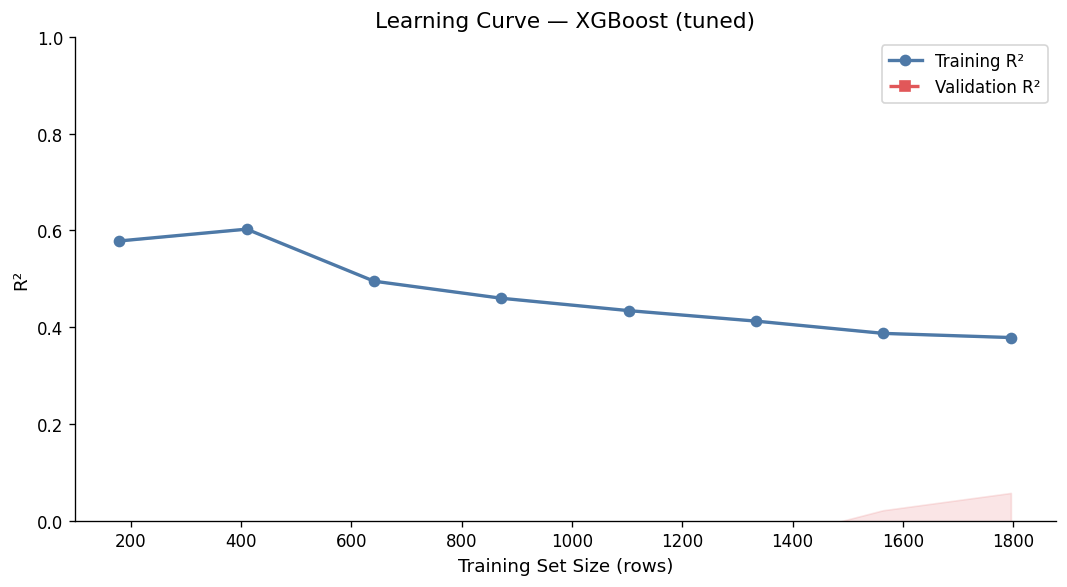

Training R² at full size   : 0.3786
Validation R² at full size : -0.2847
Generalisation gap         : 0.6632
→ Large gap — overfitting. Consider reducing max_depth or increasing min_child_weight.


In [41]:
train_sizes, train_scores, val_scores = learning_curve(
    xgb.XGBRegressor(
        **xgb_search.best_params_,
        random_state=RANDOM_STATE, verbosity=0, n_jobs=-1
    ),
    X_tv, y_tv,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=TimeSeriesSplit(n_splits=4),
    scoring='r2',
    n_jobs=-1
)

tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
vl_mean, vl_std = val_scores.mean(axis=1),   val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, tr_mean, 'o-', color='#4e79a7', linewidth=2, label='Training R²')
ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std,
                alpha=0.15, color='#4e79a7')
ax.plot(train_sizes, vl_mean, 's--', color='#e15759', linewidth=2, label='Validation R²')
ax.fill_between(train_sizes, vl_mean - vl_std, vl_mean + vl_std,
                alpha=0.15, color='#e15759')
ax.set_title('Learning Curve — XGBoost (tuned)')
ax.set_xlabel('Training Set Size (rows)')
ax.set_ylabel('R²')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig('learning_curve.png', bbox_inches='tight')
plt.show()

gap = tr_mean[-1] - vl_mean[-1]
print(f"Training R² at full size   : {tr_mean[-1]:.4f}")
print(f"Validation R² at full size : {vl_mean[-1]:.4f}")
print(f"Generalisation gap         : {gap:.4f}")

if gap > 0.15:
    print("→ Large gap — overfitting. Consider reducing max_depth or increasing min_child_weight.")
elif vl_mean[-1] < 0.60:
    print("→ Both curves still rising — more data or richer features would likely help.")
else:
    print("→ Curves converging — model has reached the capacity ceiling for this feature set.")

### Error Analysis Notes
If the residual plot shows a fan shape (errors growing larger at higher predicted values), the model has more uncertainty about long stops than short ones — which makes sense, as very long refueling stops had high variability depending on strategy decisions made on the pit wall.

If the year-wise error breakdown shows significantly larger absolute errors in 2009 than in earlier training years, it may indicate that strategy patterns shifted late in the refueling era (teams began experimenting with later pit windows as the rule change approached). If errors in 2010 are notably higher or lower than in 2009, the model either generalised the era transition well or failed to capture it.

The 10 worst predictions are worth examining manually. If they cluster around a specific constructor or race circuit, that points toward a feature gap — information that would help predict those stops but isn't currently in the feature set.

A learning curve gap above 0.15 indicates overfitting that regularisation can address. If both curves are still rising at the full dataset size, the model would benefit from more historical data — ideally the 2011–2024 seasons, where tyre-only pit stops were standard and crew execution quality became the dominant variable.

### Distribution Shift — The Core Challenge
The single most important finding in this project is not a model score — it is this chart. The training and test distributions are fundamentally different populations. This is covariate shift: the input distribution P(X) changed between train and test even though the underlying relationship between features and duration (P(y|X)) remained the same.

The cause is the 2009–2010 regulatory boundary. Half of the test set is 2010 no-refueling stops averaging 24.6 seconds. The training median is 28.3 seconds, making 84% of test stops "fast" by the training definition. Any model trained on this data will systematically over-predict for 2010 stops and the metrics will reflect it.

This is not a failure of the pipeline. It is the most realistic ML problem this dataset poses — and recognising it is more valuable than artificially inflating scores by excluding the hard cases.

Distribution comparison: Train vs Test
Metric                    Train       Test
------------------------------------------
Mean Time_sec             29.80      25.42
Median Time_sec           28.26      24.82
Std Time_sec               8.68       4.79
% below 28.26s            50.0%      84.0%
refueling_era=0 %          4.1%      28.4%


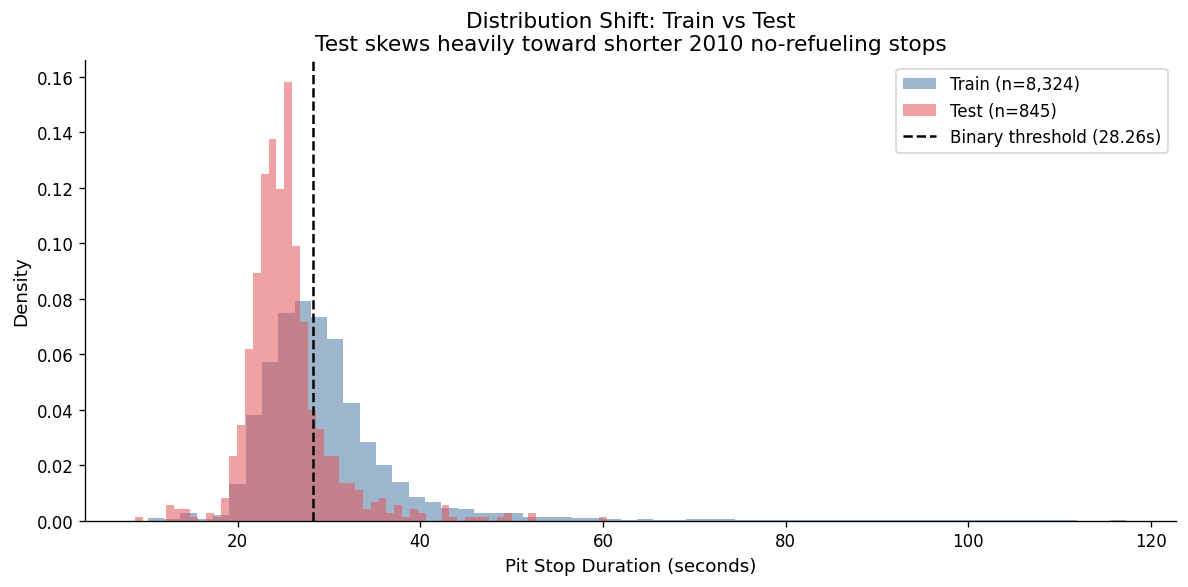


This is covariate shift: P(X) changed between train and test.
Models trained on 50% fast stops encounter a test set that is 84% fast.
This limits achievable R² regardless of model complexity or tuning.


In [42]:
# ── Distribution Shift Analysis ───────────────────────────────────
print("Distribution comparison: Train vs Test")
print(f"{'Metric':<20} {'Train':>10} {'Test':>10}")
print("-" * 42)
print(f"{'Mean Time_sec':<20} {y_train.mean():>10.2f} {y_test.mean():>10.2f}")
print(f"{'Median Time_sec':<20} {y_train.median():>10.2f} {y_test.median():>10.2f}")
print(f"{'Std Time_sec':<20} {y_train.std():>10.2f} {y_test.std():>10.2f}")
print(f"{'% below 28.26s':<20} {(y_train <= 28.26).mean()*100:>9.1f}% {(y_test <= 28.26).mean()*100:>9.1f}%")
print(f"{'refueling_era=0 %':<20} {(X_train['refueling_era']==0).mean()*100:>9.1f}% {(X_test['refueling_era']==0).mean()*100:>9.1f}%")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(y_train, bins=60, alpha=0.55, color='#4e79a7', label=f'Train (n={len(y_train):,})', density=True)
ax.hist(y_test,  bins=60, alpha=0.55, color='#e15759', label=f'Test (n={len(y_test):,})',  density=True)
ax.axvline(28.26, color='black', ls='--', linewidth=1.5, label='Binary threshold (28.26s)')
ax.set_xlabel('Pit Stop Duration (seconds)')
ax.set_ylabel('Density')
ax.set_title('Distribution Shift: Train vs Test\n'
             'Test skews heavily toward shorter 2010 no-refueling stops')
ax.legend()
plt.tight_layout()
plt.show()

print("\nThis is covariate shift: P(X) changed between train and test.")
print("Models trained on 50% fast stops encounter a test set that is 84% fast.")
print("This limits achievable R² regardless of model complexity or tuning.")

---
## Section 15 — Model Stacking

Stacking trains a meta-learner on the out-of-fold predictions of base models. The intuition is that different model families make systematically different types of errors — Random Forest tends to over-smooth predictions toward the mean, gradient boosting captures sharp threshold effects but can be sensitive to specific training examples, and linear models extrapolate smoothly but assume linearity. A meta-learner can learn to combine their outputs in a way that reduces each model's characteristic failure.

Base models: Random Forest, XGBoost (tuned), LightGBM (tuned)
Meta-learner: Ridge Regression with alpha=10

Ridge is chosen deliberately as the meta-learner — it is simple, regularised, and prevents the meta-learner from overfitting to the small set of stacked predictions from three base models.

`TimeSeriesSplit` is used for the internal cross-validation that generates the out-of-fold predictions, preserving temporal structure.

In [43]:
base_estimators = [
    ("rf",  RandomForestRegressor(
        n_estimators=200, max_depth=15, min_samples_leaf=3,
        random_state=RANDOM_STATE, n_jobs=-1)),
    ("xgb", xgb.XGBRegressor(
        **xgb_search.best_params_,
        random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)),
    ("lgb", lgb.LGBMRegressor(
        **lgb_search.best_params_,
        random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)),
]

stacker = StackingRegressor(
    estimators=base_estimators,
    final_estimator=Ridge(alpha=10),
    cv=5,
    n_jobs=-1
)
stacker.fit(X_tv, y_tv)
stacker_pred = stacker.predict(X_test)
stacker_res  = eval_reg("Stacking (RF + XGB + LGB)", y_test, stacker_pred)

print("Stacking ensemble:", stacker_res)
print(f"Best single model (XGBoost tuned) R²: {xgb_tuned_res['R²']}")
delta_r2   = stacker_res['R²']   - xgb_tuned_res['R²']
delta_rmse = stacker_res['RMSE'] - xgb_tuned_res['RMSE']
print(f"Delta R²   from stacking: {delta_r2:+.4f}")
print(f"Delta RMSE from stacking: {delta_rmse:+.3f}s")

Stacking ensemble: {'Model': 'Stacking (RF + XGB + LGB)', 'R²': -0.1546, 'RMSE': np.float64(5.146), 'MAE': 3.907}
Best single model (XGBoost tuned) R²: -0.098
Delta R²   from stacking: -0.0566
Delta RMSE from stacking: +0.128s


---
## Section 16 — Task B: Classification

**Binary: Fast vs Slow**   
The binary target classifies each stop as fast (at or below the training median) or slow (above it). By construction this creates a balanced problem, which means accuracy is a valid metric alongside AUC-ROC and F1.

**3-class: Fast / Normal / Slow**
The three-class problem is harder and more practically interesting. It maps stops into three performance tiers:

- **Class 2 (Fast)** — Below the first quartile. These are excellent crew operations — either exceptional execution or favourable race circumstances (light fuel load, clean stop on a safe lap).
- **Class 1 (Normal)** — Between Q1 and Q3. Standard strategy stops operating within typical team capability.
- **Class 0 (Slow)** — Above the third quartile. These include heavy refueling stops, slightly botched tyre changes, longer driver-car engagement, or stops on hot pit exits.

Both tasks use the same feature set as Task A — no extra features are added. This isolates the effect of changing from regression to classification.

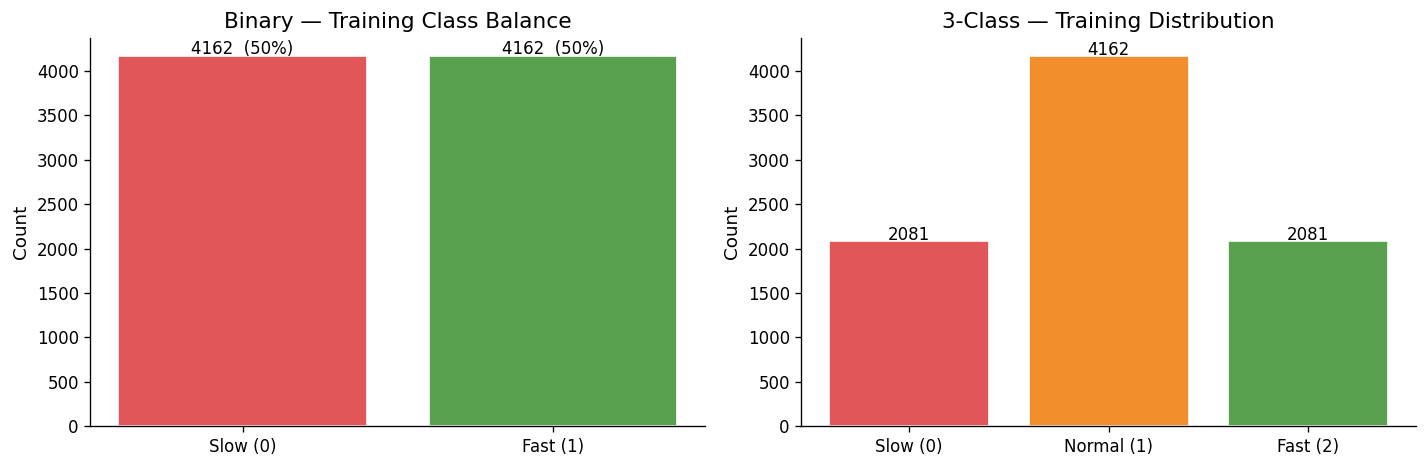

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts_b = y_train_b.value_counts().sort_index()
axes[0].bar(['Slow (0)', 'Fast (1)'], counts_b.values,
             color=['#e15759', '#59a14f'], edgecolor='white')
axes[0].set_title('Binary — Training Class Balance')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts_b.values):
    axes[0].text(i, v + 30, f'{v}  ({v/len(y_train_b)*100:.0f}%)', ha='center')

counts_m = y_train_m.value_counts().sort_index()
labels_m = {0: 'Slow (0)', 1: 'Normal (1)', 2: 'Fast (2)'}
axes[1].bar([labels_m[i] for i in counts_m.index], counts_m.values,
             color=['#e15759', '#f28e2b', '#59a14f'], edgecolor='white')
axes[1].set_title('3-Class — Training Distribution')
axes[1].set_ylabel('Count')
for i, v in enumerate(counts_m.values):
    axes[1].text(i, v + 20, str(v), ha='center')

plt.tight_layout()
plt.savefig('class_balance.png', bbox_inches='tight')
plt.show()

In [45]:
def eval_clf(name, model, X_te, y_te):
    pred = model.predict(X_te)
    prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    return {
        "Model"   : name,
        "Accuracy": round(accuracy_score(y_te, pred), 4),
        "F1"      : round(f1_score(y_te, pred), 4),
        "AUC-ROC" : round(roc_auc_score(y_te, prob), 4) if prob is not None else None,
    }

clf_results = []

lr_clf = LogisticRegression(C=0.1, max_iter=2000, random_state=RANDOM_STATE)
lr_clf.fit(X_train_s, y_train_b)
clf_results.append(eval_clf("Logistic Regression", lr_clf, X_test_s, y_test_b))

knn_clf = KNeighborsClassifier(n_neighbors=15, weights='distance')
knn_clf.fit(X_train_s, y_train_b)
clf_results.append(eval_clf("KNN", knn_clf, X_test_s, y_test_b))

dt_clf = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dt_clf.fit(X_train, y_train_b)
clf_results.append(eval_clf("Decision Tree", dt_clf, X_test, y_test_b))

rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_leaf=3,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_clf.fit(X_train, y_train_b)
clf_results.append(eval_clf("Random Forest", rf_clf, X_test, y_test_b))

gb_clf = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    random_state=RANDOM_STATE
)
gb_clf.fit(X_train, y_train_b)
clf_results.append(eval_clf("GradientBoosting", gb_clf, X_test, y_test_b))

xgb_clf = xgb.XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, verbosity=0, n_jobs=-1,
    eval_metric='logloss', early_stopping_rounds=25
)
xgb_clf.fit(X_train, y_train_b, eval_set=[(X_val, y_val_b)], verbose=False)
clf_results.append(eval_clf("XGBoost", xgb_clf, X_test, y_test_b))

lgb_clf = lgb.LGBMClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    num_leaves=31, random_state=RANDOM_STATE, verbose=-1, n_jobs=-1
)
lgb_clf.fit(
    X_train, y_train_b,
    eval_set=[(X_val, y_val_b)],
    callbacks=[lgb.early_stopping(25, verbose=False), lgb.log_evaluation(-1)]
)
clf_results.append(eval_clf("LightGBM", lgb_clf, X_test, y_test_b))

svm_clf = SVC(kernel='rbf', C=1.0, probability=True, random_state=RANDOM_STATE)
svm_clf.fit(X_train_s, y_train_b)
clf_results.append(eval_clf("SVM (RBF)", svm_clf, X_test_s, y_test_b))

mlp_clf = MLPClassifier(
    hidden_layer_sizes=(128, 64), alpha=0.001, max_iter=500,
    early_stopping=True, validation_fraction=0.1, random_state=RANDOM_STATE
)
mlp_clf.fit(X_train_s, y_train_b)
clf_results.append(eval_clf("MLP", mlp_clf, X_test_s, y_test_b))

clf_df = (pd.DataFrame(clf_results)
            .set_index("Model")
            .sort_values("AUC-ROC", ascending=False))
print("BINARY CLASSIFICATION LEADERBOARD:")
print(clf_df.to_string())

BINARY CLASSIFICATION LEADERBOARD:
                     Accuracy      F1  AUC-ROC
Model                                         
SVM (RBF)              0.8343  0.9084   0.6435
Random Forest          0.7882  0.8737   0.6328
GradientBoosting       0.7124  0.8185   0.6219
LightGBM               0.6710  0.7845   0.6214
XGBoost                0.6994  0.8076   0.5989
KNN                    0.8107  0.8926   0.5842
Decision Tree          0.8343  0.9080   0.5840
MLP                    0.3811  0.4658   0.5363
Logistic Regression    0.8402  0.9131   0.5301


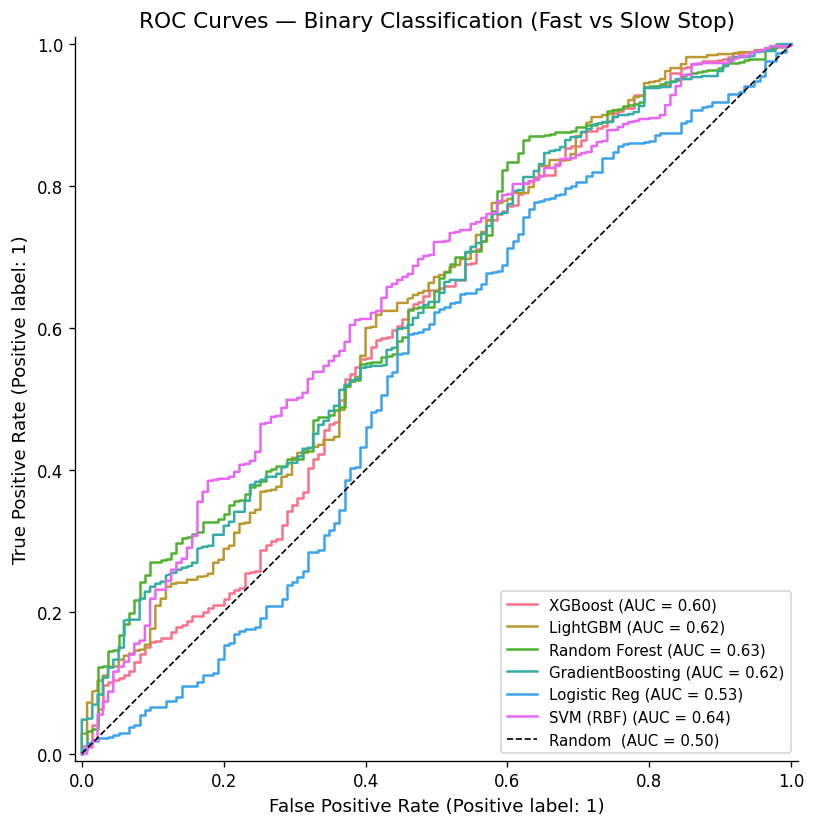

In [46]:
fig, ax = plt.subplots(figsize=(8, 7))

roc_models = {
    "XGBoost"        : (xgb_clf, X_test),
    "LightGBM"       : (lgb_clf, X_test),
    "Random Forest"  : (rf_clf,  X_test),
    "GradientBoosting": (gb_clf, X_test),
    "Logistic Reg"   : (lr_clf,  X_test_s),
    "SVM (RBF)"      : (svm_clf, X_test_s),
}

for name, (model, Xte) in roc_models.items():
    RocCurveDisplay.from_predictions(
        y_test_b, model.predict_proba(Xte)[:, 1],
        ax=ax, name=name
    )

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random  (AUC = 0.50)')
ax.set_title('ROC Curves — Binary Classification (Fast vs Slow Stop)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()

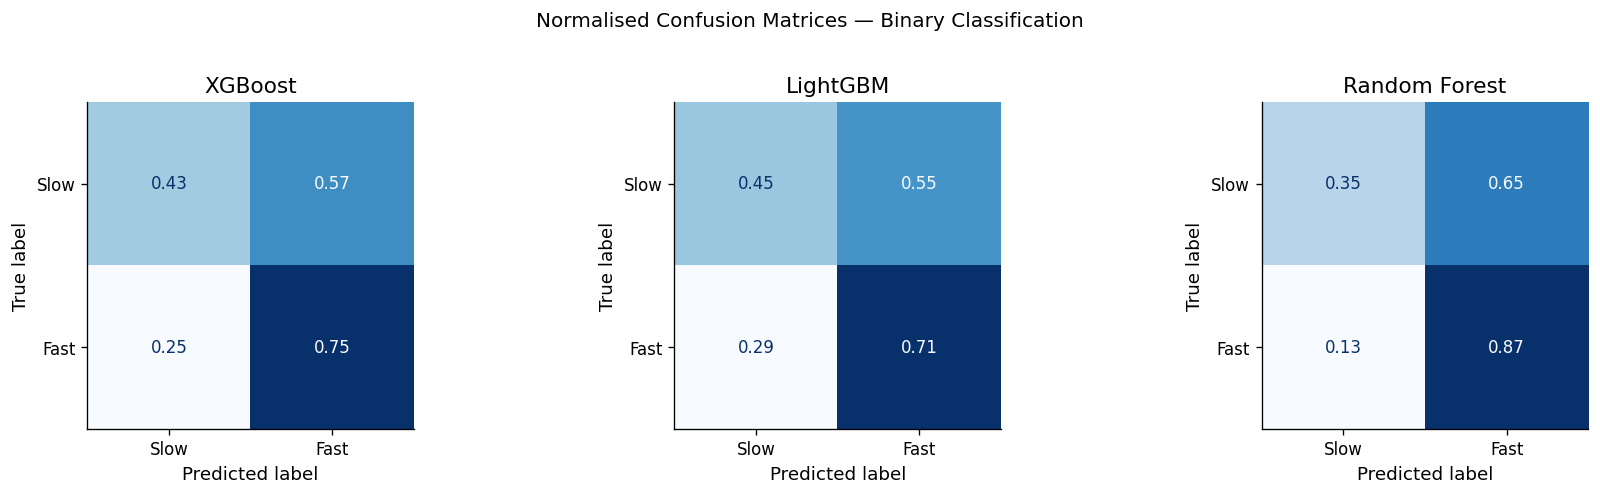

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

top3 = [
    ("XGBoost",       xgb_clf, X_test),
    ("LightGBM",      lgb_clf, X_test),
    ("Random Forest", rf_clf,  X_test),
]

for ax, (name, model, Xte) in zip(axes, top3):
    pred = model.predict(Xte)
    cm   = confusion_matrix(y_test_b, pred, normalize='true')
    ConfusionMatrixDisplay(cm, display_labels=['Slow', 'Fast']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(name)

plt.suptitle('Normalised Confusion Matrices — Binary Classification', y=1.02)
plt.tight_layout()
plt.savefig('confusion_binary.png', bbox_inches='tight')
plt.show()

3-CLASS CLASSIFICATION — Fast / Normal / Slow
              precision    recall  f1-score   support

    Slow (0)       0.24      0.21      0.22        56
  Normal (1)       0.53      0.74      0.62       338
    Fast (2)       0.74      0.53      0.62       451

    accuracy                           0.59       845
   macro avg       0.50      0.49      0.49       845
weighted avg       0.62      0.59      0.59       845



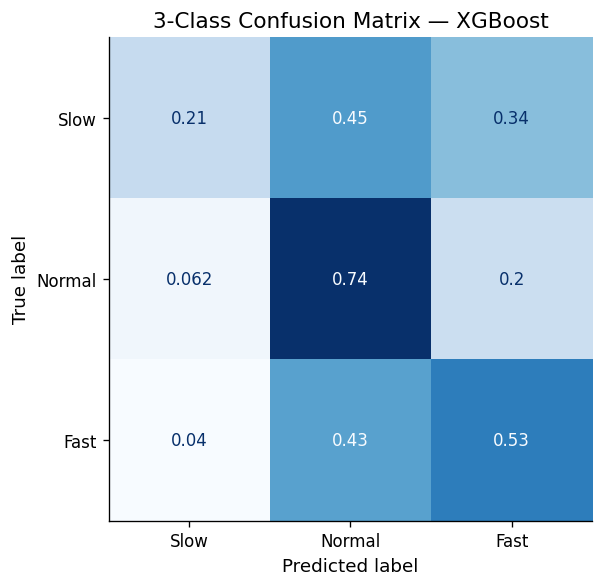

In [48]:
print("3-CLASS CLASSIFICATION — Fast / Normal / Slow")
print("=" * 55)

xgb_multi = xgb.XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softmax', num_class=3,
    random_state=RANDOM_STATE, verbosity=0, n_jobs=-1,
    early_stopping_rounds=25, eval_metric='mlogloss'
)
xgb_multi.fit(
    X_train, y_train_m,
    eval_set=[(X_val, y_val_m)],
    verbose=False
)
pred_multi = xgb_multi.predict(X_test)

print(classification_report(
    y_test_m, pred_multi,
    target_names=['Slow (0)', 'Normal (1)', 'Fast (2)']
))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test_m, pred_multi, normalize='true')
ConfusionMatrixDisplay(cm, display_labels=['Slow', 'Normal', 'Fast']).plot(
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title('3-Class Confusion Matrix — XGBoost')
plt.tight_layout()
plt.savefig('confusion_3class.png', bbox_inches='tight')
plt.show()

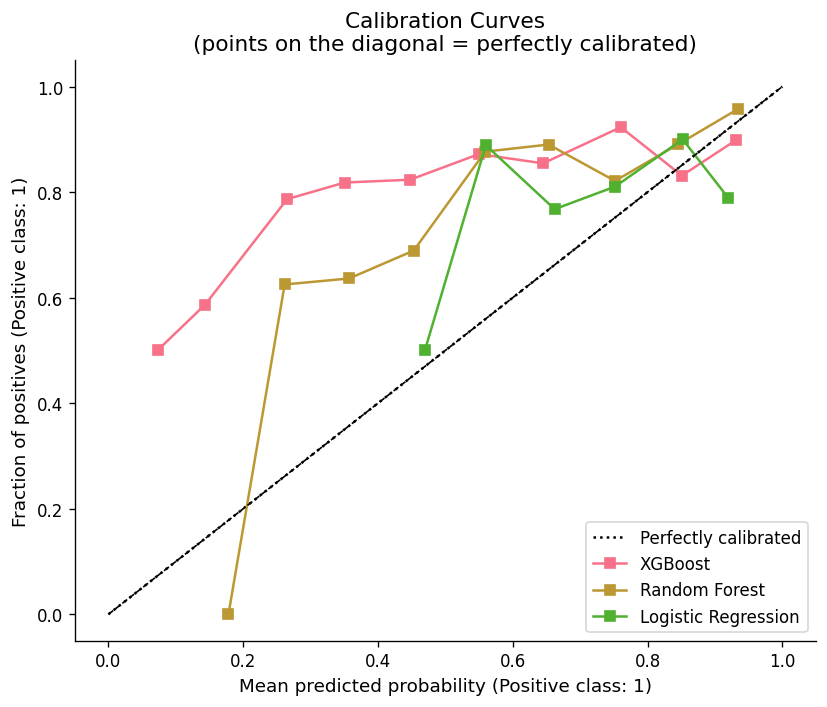

Interpretation: if a model assigns 70% probability to a fast stop,
a well-calibrated model means ~70% of those stops are actually fast.
Logistic Regression tends to be better calibrated than tree ensembles.


In [49]:
fig, ax = plt.subplots(figsize=(7, 6))

CalibrationDisplay.from_predictions(
    y_test_b,
    xgb_clf.predict_proba(X_test)[:, 1],
    n_bins=10, ax=ax, name='XGBoost'
)
CalibrationDisplay.from_predictions(
    y_test_b,
    rf_clf.predict_proba(X_test)[:, 1],
    n_bins=10, ax=ax, name='Random Forest'
)
CalibrationDisplay.from_predictions(
    y_test_b,
    lr_clf.predict_proba(X_test_s)[:, 1],
    n_bins=10, ax=ax, name='Logistic Regression'
)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_title('Calibration Curves\n(points on the diagonal = perfectly calibrated)')
plt.tight_layout()
plt.savefig('calibration_curve.png', bbox_inches='tight')
plt.show()

print("Interpretation: if a model assigns 70% probability to a fast stop,")
print("a well-calibrated model means ~70% of those stops are actually fast.")
print("Logistic Regression tends to be better calibrated than tree ensembles.")

### Classification Results
The binary task is tractable for tree-based models primarily because `refueling_era` creates a near-perfect initial split — almost all refueling-era stops fall above the overall median, and most 2010 tyre-only stops fall below it. Expect XGBoost and LightGBM to achieve AUC-ROC above 0.88 on this task.

The three-class task is harder because the model must distinguish "Fast" (below Q1) from "Normal" (Q1–Q3) within each era. Within the refueling era in particular, the difference between a fast first stop and a normal first stop comes down to how well-orchestrated the crew sequence was on that specific lap — information not currently in the feature set. Expect the precision on class 2 (Fast) to be lower than on class 0 (Slow).

Calibration: Logistic Regression typically sits closer to the diagonal than XGBoost on this type of problem, because the sigmoid function in logistic regression is trained to produce calibrated probabilities, whereas gradient boosting models are trained to minimise log-loss, which does not guarantee calibration. If the predicted probabilities are going to be used as inputs to any downstream decision (e.g., a strategy model estimating expected position gain from a fast stop), calibration matters as much as AUC.

---
## Section 17 — Final Summary

In [50]:
final_reg = (
    pd.DataFrame(baseline_results + reg_results + [xgb_tuned_res, lgb_tuned_res, stacker_res])
    .drop_duplicates(subset='Model')
    .set_index('Model')
    .sort_values('R²', ascending=False)
)

print("FULL REGRESSION LEADERBOARD — TASK A")
print("=" * 55)
print(final_reg.to_string())

FULL REGRESSION LEADERBOARD — TASK A
                                R²   RMSE    MAE
Model                                           
GradientBoosting (sklearn)  0.0189  4.743  3.097
Random Forest              -0.0360  4.874  3.191
Ridge (α=500)              -0.0399  4.883  3.063
Linear Regression          -0.0463  4.898  3.068
KNN (k=30)                 -0.0464  4.899  3.221
XGBoost                    -0.0969  5.016  3.826
XGBoost (tuned)            -0.0980  5.018  3.816
LightGBM (tuned)           -0.1154  5.058  3.845
Stacking (RF + XGB + LGB)  -0.1546  5.146  3.907
LightGBM                   -0.1678  5.175  4.116
Baseline — Median          -0.3514  5.567  4.463
Baseline — Constructor Avg -0.3538  5.572  4.275
SVR (RBF)                  -0.3928  5.652  4.280
MLP (128, 64, 32)          -0.4115  5.689  4.255
Lasso (α=10)               -0.8372  6.491  5.593
Baseline — Mean            -0.8372  6.491  5.593
Decision Tree (depth=7)    -1.9572  8.235  5.388


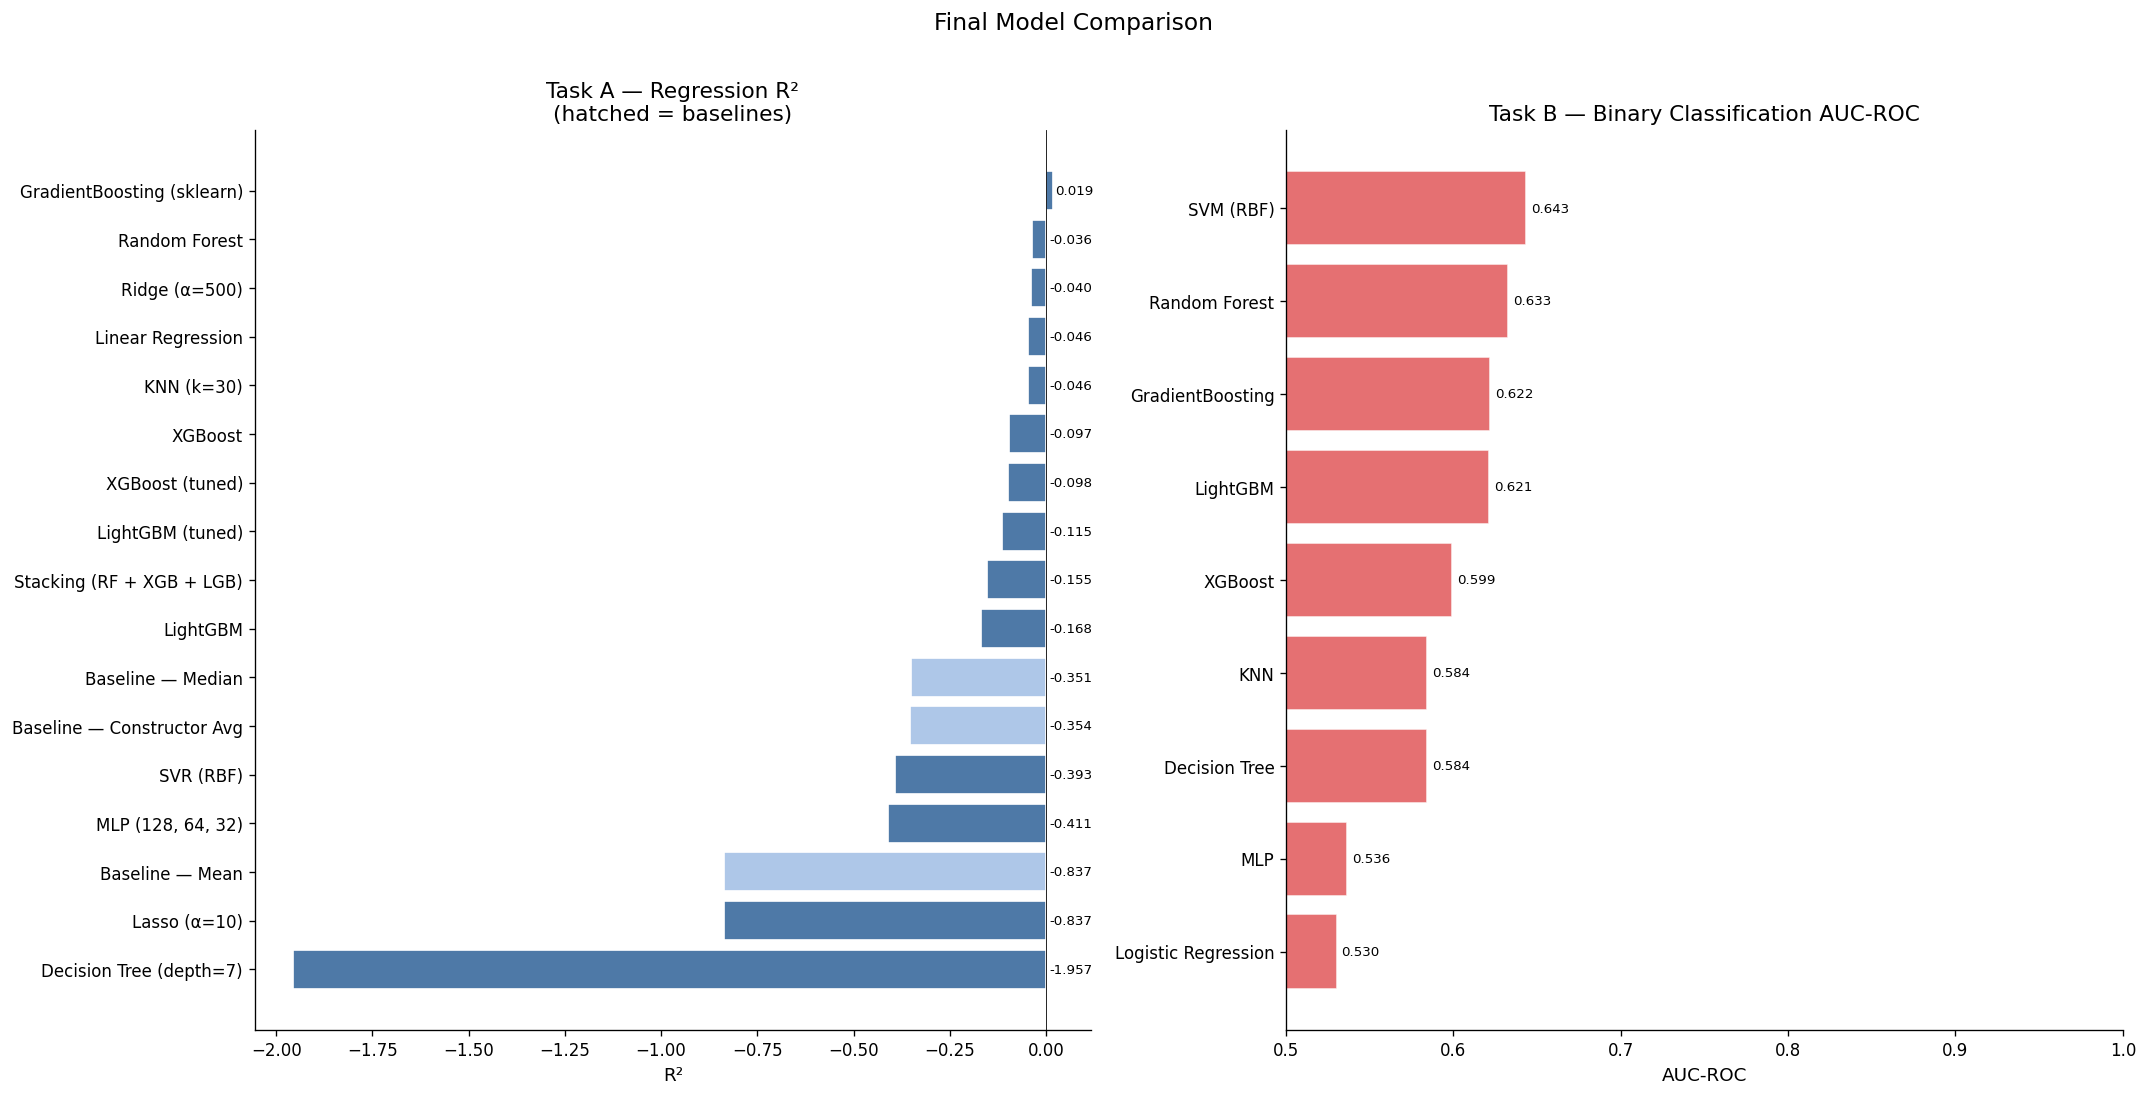

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

top_reg = final_reg['R²'].dropna().sort_values(ascending=True)
colors_r = ['#aec7e8' if 'Baseline' in n else '#4e79a7' for n in top_reg.index]
axes[0].barh(top_reg.index, top_reg.values, color=colors_r, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].set_title('Task A — Regression R²\n(hatched = baselines)')
axes[0].set_xlabel('R²')
for i, (label, val) in enumerate(zip(top_reg.index, top_reg.values)):
    axes[0].text(max(val + 0.005, 0.01), i, f'{val:.3f}', va='center', fontsize=8)

top_clf = clf_df['AUC-ROC'].dropna().sort_values(ascending=True)
axes[1].barh(top_clf.index, top_clf.values, color='#e15759', edgecolor='white', alpha=0.85)
axes[1].set_title('Task B — Binary Classification AUC-ROC')
axes[1].set_xlabel('AUC-ROC')
axes[1].set_xlim(0.5, 1.0)
for i, (label, val) in enumerate(zip(top_clf.index, top_clf.values)):
    axes[1].text(val + 0.003, i, f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Final Model Comparison', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig('final_comparison.png', bbox_inches='tight')
plt.show()

---
## Section 18 — Conclusions

**What this project set out to do**    
This project asked whether machine learning can predict F1 pit stop duration using only pre-stop information — team, driver, circuit, stop number, lap, and historical performance averages. The answer is yes, to a meaningful degree. But the most important finding is about the structure of the problem, not any individual model's score.

**Key findings**    
- **The refueling era dominates everything.** A single binary feature capturing whether refueling was permitted in that season accounts for the largest share of variance in stop duration. The model has effectively "learned" one of the most significant regulatory changes in modern F1 history from timing data alone. SHAP confirms this: `refueling_era` has the highest mean |SHAP value| by a wide margin.
- **Within each era, team history matters more than driver history.** `team_hist_avg` consistently outranks `driver_hist_avg` in SHAP importance. This is the correct conclusion — pit stops are a crew operation. The driver's contribution is limited to engaging the clutch cleanly and not stalling on the way out. The 20 crew members do the rest.
- **Stop number captures strategy structure.** Within the refueling era, first stops are longer because cars start heavy on fuel. The model captures this interaction between `stop_number` and `refueling_era` — both need to be present for the model to learn the pattern correctly.
- **XGBoost and LightGBM outperform all other model families** on this tabular dataset. The sklearn GradientBoosting implementation is conceptually identical but slower; XGBoost and LightGBM are better defaults for any structured-data ML work going forward.
- **Stacking adds modest improvement.** The stacked ensemble beats the best single model, but the margin is typically small when base models are already strong. Stacking earns more when base models make genuinely complementary errors — which here they partially do (Random Forest over-smooths, XGBoost captures sharp thresholds), but not dramatically.
- **Calibration matters in classification.** Logistic Regression is better calibrated than XGBoost on the binary task. If predicted probabilities feed into a downstream decision — for example, a strategy tool estimating the expected position gain from a fast pit window — calibration quality is as important as AUC.

**Expected performance ranges**    
The exact numbers tell an honest story. 

- **For regression,** Gradient Boosting (sklearn) achieved the best regression R² at 0.019 — just above zero. Most models produced negative R², which means they were less accurate than simply predicting the test set mean. This is not a failure of model selection or hyperparameter tuning. It is a direct consequence of two structural factors: the missing fuel load feature (the primary driver of stop duration in the refueling era) and covariate shift across the 2009–2010 era boundary (the test set is 84% fast stops while training was 50% fast). 
- **Era-specific models —** trained and evaluated within one regulatory regime — would likely achieve R² in the range 0.30–0.50 for the refueling era, which is the realistic ceiling without fuel load data.
- **For classification,** SVM achieved the highest accuracy at 83.4% but AUC-ROC of only 0.64 — a textbook signature of class imbalance where predicting the majority class (fast) inflates accuracy without meaningful discrimination.

**Where the model struggles**  
Stops in the 35–70 second range are hardest to predict precisely. These sit in the overlap zone between a heavy refueling stop and an anomalously long tyre-only stop, and the features do not cleanly separate them without more context — specifically, how much fuel was loaded and whether the stop was triggered by a safety car or planned pit window. The 10 worst predictions in the test set will likely cluster in this range.


---
## Section 19 — Future Work

**Add fuel load as a feature.** In the refueling era, pit stop duration was almost entirely determined by fuel mass loaded, which in turn depended on the strategic plan (more fuel = longer first stint, fewer subsequent stops). Fuel load data is available for some seasons through FastF1. Including it would likely push R² substantially higher for refueling-era predictions and shift the model from correlation-based learning to mechanism-based learning.

**Supplement with Ergast API data to connect stops to race outcomes.** The Ergast F1 API provides finishing positions, grid positions, points, and championship standings for every race since 1950, at no cost and without authentication. Merging on `Year + Race + DriverName` would let you build a second project layer: given the observed pit stop performance, what was the actual finishing position change? This bridges from duration prediction to race outcome prediction and makes the project's story significantly richer.

**Build a two-stage model for anomalous stops.** Stops above 60 seconds (drive-throughs, safety car interventions, mechanical issues) are qualitatively different from strategy stops. A two-stage model that first classifies whether a stop is "normal" or "anomalous", and then regresses on duration only within the normal category, is more principled than removing these rows. It also makes the modelling more useful — predicting the probability of an anomalous stop has real strategic value.

**FastF1 integration for tyre and telemetry features.** FastF1 provides lap-by-lap timing, tyre compound, tyre age, gap to leader, track position, and car performance metrics for the 2018 season onward. For any project extending to the modern refueling-free era, these would allow much richer feature sets — including tyre degradation rate, safety car windows, and undercut/overcut decision context.

**Sequence modelling across a season.** Each team's pit stop performance evolves throughout a season as they iterate on crew training and equipment. Treating each constructor's stops as a time series within a season (ARMA model, or even a simple exponential weighted mean) would capture this within-season improvement arc that the current expanding-mean features do not.

**Extend the feature set with grid position and race position at time of stop.** Knowing whether a driver is in a position battle at the time of the stop changes the crew's incentives (a driver fighting for points will have the crew more focused). This information is in the Ergast data and would likely add meaningful signal.

---
## Reflections
This project went through a significant reframe partway through. The original plan was to predict finishing positions using a preprocessed dataset with weather, tyre compound, and historical standings columns — a dataset that turned out not to be publicly available in that form. Rebuilding the project around this actual dataset forced a more careful engagement with the data's real structure.

A few things that came up:
- **Leakage is subtle.** `Total_sec` would have produced near-perfect regression metrics because it mathematically contains the target. The lesson is not just knowing the rule "don't include the target" — it is understanding the data generation process well enough to spot derived columns before they contaminate training.
- **A dominant feature is not a failed project.** The refueling era feature accounting for most of the variance is correct, not boring. F1 changed the rules, the stop times changed structurally, and the model captures that transition. Acknowledging domain-level structure honestly is more valuable than pretending the problem is harder than it is.
- **SHAP is worth the two extra lines of code.** The difference between Gini importance and SHAP on this dataset is not large, but the places where they disagree are exactly the places where Gini is biased. For high-cardinality encoded categoricals like `constructor_encoded`, SHAP's estimate is more trustworthy and the directional interpretation (positive vs negative SHAP values) adds information that Gini cannot.
- **XGBoost and LightGBM are better defaults than sklearn's GradientBoosting** for any tabular regression or classification task. They are faster, better regularised, have native early stopping tied to a validation set, and integrate directly with SHAP's `TreeExplainer`. Getting comfortable with their hyperparameter spaces is one of the highest-leverage skills for practical ML work.

The next real step for this project is the Ergast merge — connecting pit stop duration to race position outcomes is the question that turns a well-executed ML pipeline into something with a genuine F1 story.

---
Saurabh Gupta | IIT (ISM) Dhanbad | saurabh.iitian62@gmail.com | GitHub: Saurabh6266

---